<a href="https://colab.research.google.com/github/sandeepkodavati36/electricity-forecast-india/blob/main/Electricity_Forecast_2025_2027ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install xgboost statsmodels plotly

## Step 2: Generate Realistic Indian States Dataset

This step generates a synthetic dataset for monthly electricity bills across 8 Indian states from 2019 to 2023. The data includes variations to simulate real-world scenarios, such as baseline consumption, seasonal changes, and random fluctuations.

In [2]:
import pandas as pd
import numpy as np

# Define the states and date range
indian_states = [
    'Maharashtra', 'Uttar Pradesh', 'Tamil Nadu', 'Karnataka',
    'Gujarat', 'Rajasthan', 'West Bengal', 'Madhya Pradesh'
]

start_date = '2019-01-01'
end_date = '2023-12-31'

# Generate all months in the date range
dates = pd.date_range(start=start_date, end=end_date, freq='MS')

# Initialize an empty list to store data for each state
data = []

# Base electricity consumption for each state (in kWh, for simulation)
# These are arbitrary values chosen to show variation.
state_base_kwh = {
    'Maharashtra': 150,
    'Uttar Pradesh': 180,
    'Tamil Nadu': 130,
    'Karnataka': 140,
    'Gujarat': 160,
    'Rajasthan': 170,
    'West Bengal': 120,
    'Madhya Pradesh': 155
}

# Approximate average tariff per kWh (INR) for residential consumers
# This is a simplified average and can vary greatly by state and consumption slab.
tariff_per_kwh = 7.5 # INR

for state in indian_states:
    base_kwh = state_base_kwh[state]
    for date in dates:
        month = date.month
        year = date.year

        # Introduce seasonality for electricity consumption
        # Higher consumption in summer (April-July) and winter (Nov-Feb) due to AC/heaters
        # Lower consumption in monsoon/mild seasons
        seasonal_factor = 1.0
        if month in [4, 5, 6, 7]: # Summer months
            seasonal_factor = np.random.uniform(1.2, 1.5) # 20-50% increase
        elif month in [11, 12, 1, 2]: # Winter months
            seasonal_factor = np.random.uniform(1.0, 1.2) # 0-20% increase (could be heating or just base)
        else: # Monsoon/mild months
            seasonal_factor = np.random.uniform(0.8, 1.0) # 0-20% decrease

        # Add a slight increasing trend over years for general growth
        trend_factor = 1 + ((year - 2019) * 0.02) # 2% annual growth

        # Add random noise
        noise = np.random.normal(0, 10) # Random fluctuations in kWh

        # Calculate monthly kWh consumption
        kwh_consumption = (base_kwh * seasonal_factor * trend_factor) + noise
        kwh_consumption = max(50, round(kwh_consumption, 2)) # Ensure consumption is not too low

        # Calculate monthly bill
        monthly_bill_inr = round(kwh_consumption * tariff_per_kwh, 2)

        data.append({
            'State': state,
            'Date': date,
            'Year': year,
            'Month': month,
            'Monthly_Consumption_kWh': kwh_consumption,
            'Monthly_Bill_INR': monthly_bill_inr
        })

# Create DataFrame
df = pd.DataFrame(data)

# Display the first few rows and information about the DataFrame
display(df.head())
display(df.info())


,State,Date,Year,Month,Monthly_Consumption_kWh,Monthly_Bill_INR
0,Maharashtra,2019-01-01,2019,1,174.52,1308.90
1,Maharashtra,2019-02-01,2019,2,152.67,1145.02
2,Maharashtra,2019-03-01,2019,3,147.47,1106.03
3,Maharashtra,2019-04-01,2019,4,197.71,1482.83
4,Maharashtra,2019-05-01,2019,5,182.05,1365.38


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   State                    480 non-null    object        
 1   Date                     480 non-null    datetime64[ns]
 2   Year                     480 non-null    int64         
 3   Month                    480 non-null    int64         
 4   Monthly_Consumption_kWh  480 non-null    float64       
 5   Monthly_Bill_INR         480 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 22.6+ KB


None

## Step 3: Exploratory Data Analysis (EDA)

In this step, we will perform Exploratory Data Analysis to understand the data distribution, identify trends, seasonality, and other potential patterns in the monthly electricity bills across Indian states.

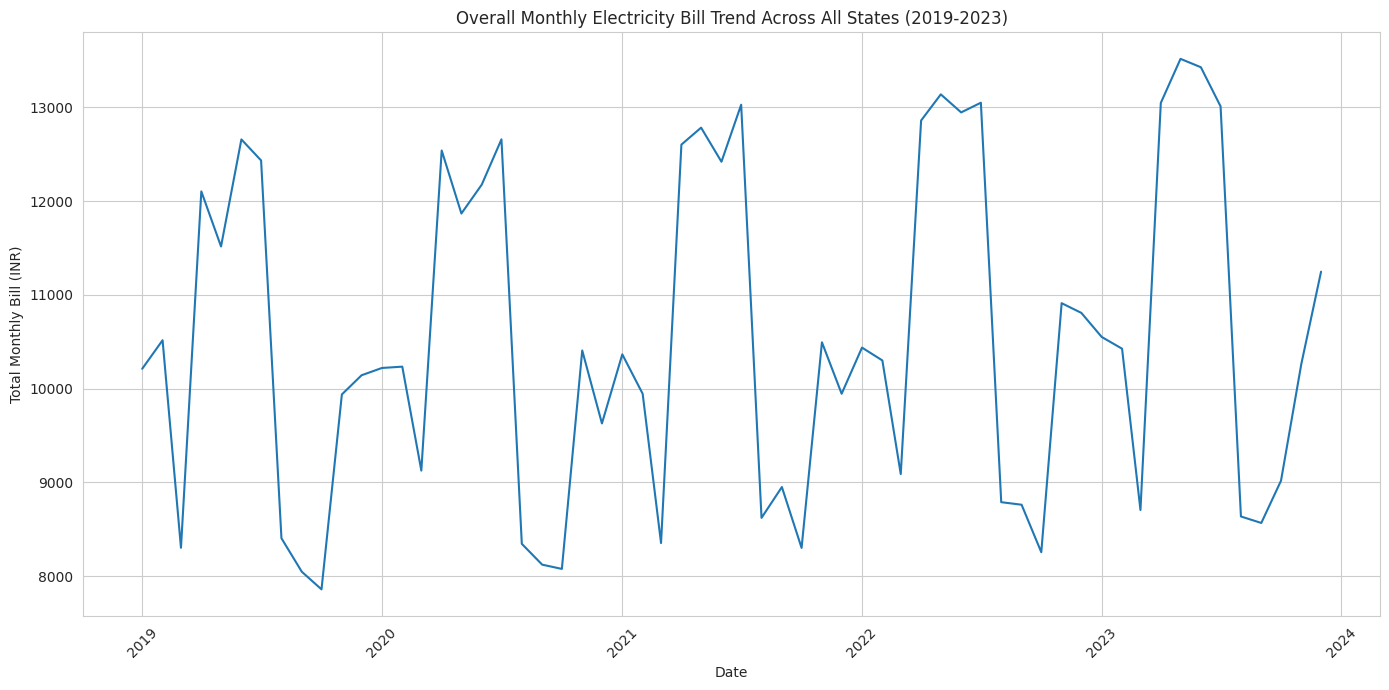

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# 1. Overall Monthly Bill Trend
overall_monthly_bill = df.groupby('Date')['Monthly_Bill_INR'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Monthly_Bill_INR', data=overall_monthly_bill)
plt.title('Overall Monthly Electricity Bill Trend Across All States (2019-2023)')
plt.xlabel('Date')
plt.ylabel('Total Monthly Bill (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### State-wise Monthly Bill Trends

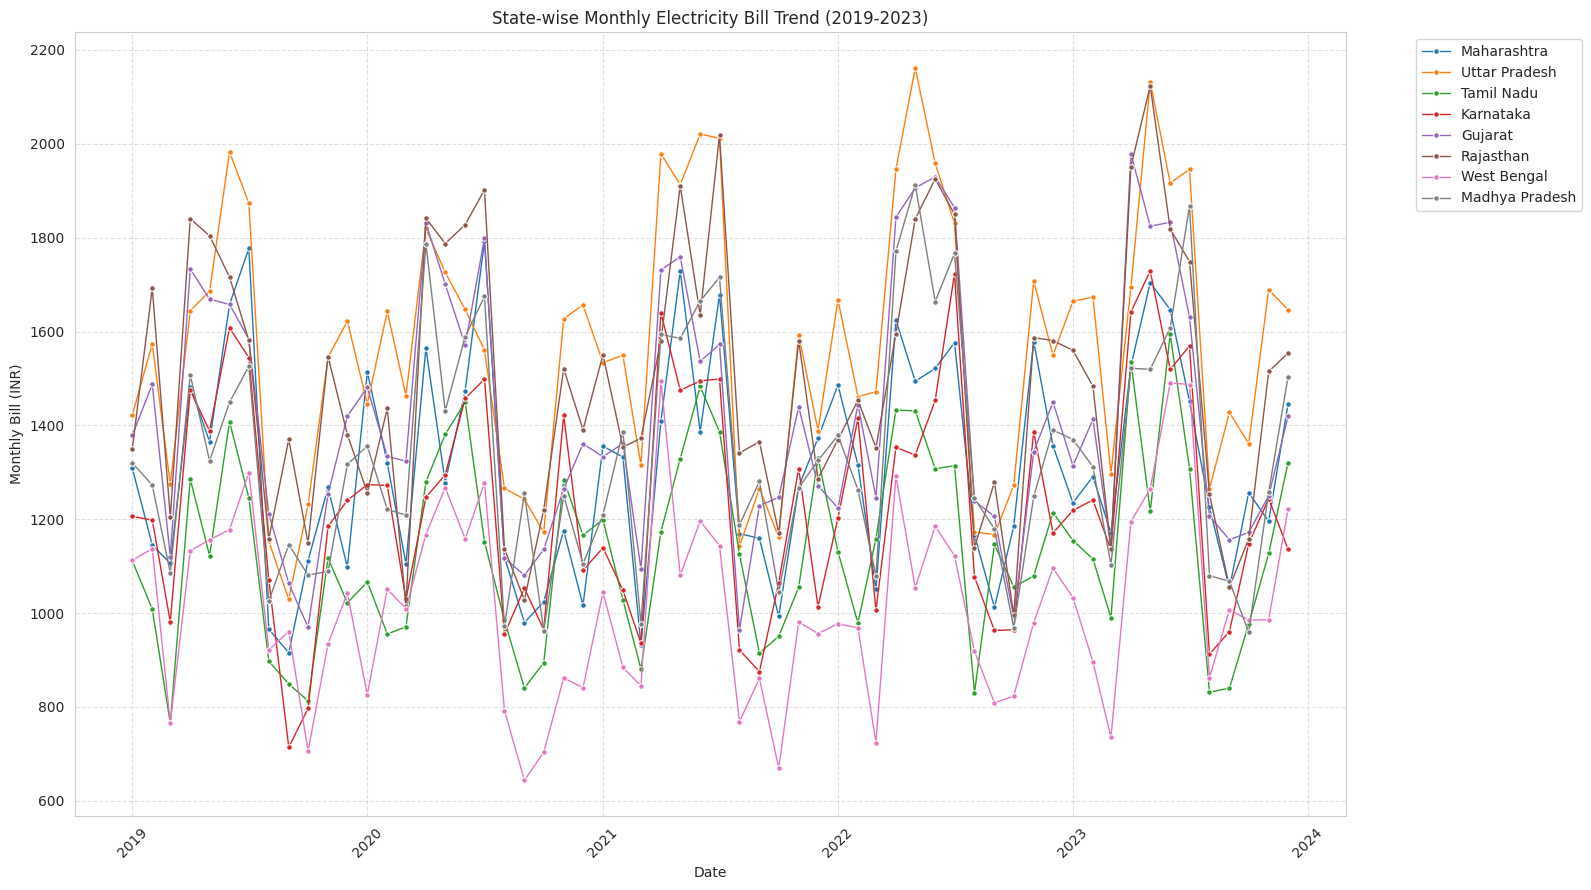

In [4]:
# 2. State-wise Monthly Bill Trends
plt.figure(figsize=(16, 9))
sns.lineplot(x='Date', y='Monthly_Bill_INR', hue='State', data=df, marker='o', markersize=4, lw=1)
plt.title('State-wise Monthly Electricity Bill Trend (2019-2023)')
plt.xlabel('Date')
plt.ylabel('Monthly Bill (INR)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Seasonality Analysis

/tmp/ipykernel_7082/3788356135.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Monthly_Bill_INR', data=average_bill_by_month, palette='viridis')


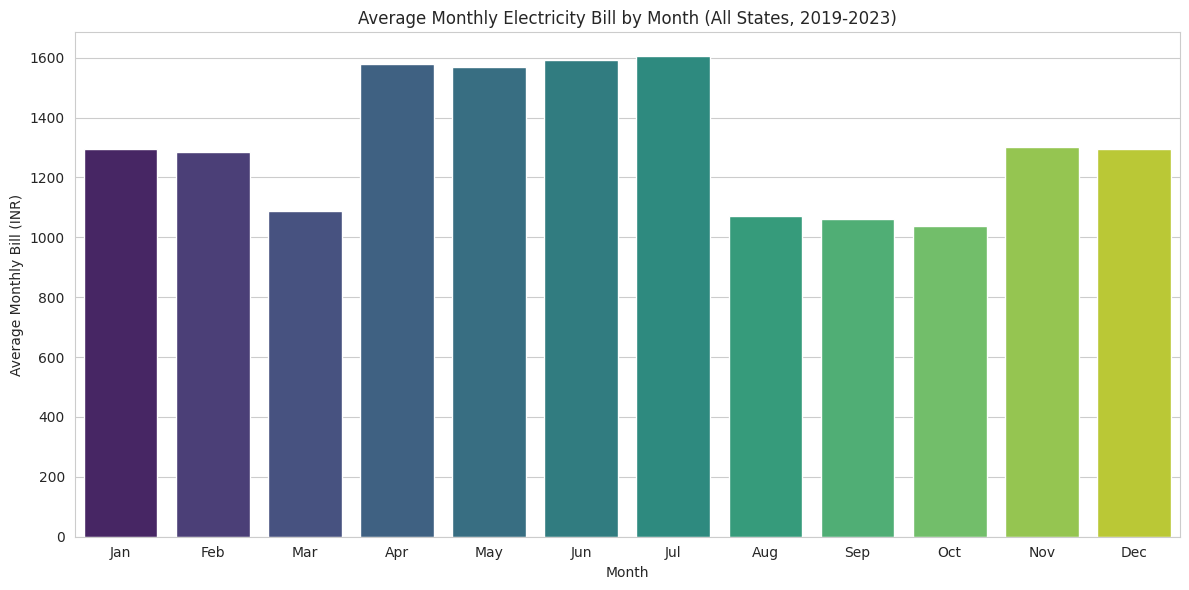

In [5]:
# 3. Seasonality Bar Chart (Average Monthly Bill by Month)
average_bill_by_month = df.groupby('Month')['Monthly_Bill_INR'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Monthly_Bill_INR', data=average_bill_by_month, palette='viridis')
plt.title('Average Monthly Electricity Bill by Month (All States, 2019-2023)')
plt.xlabel('Month')
plt.ylabel('Average Monthly Bill (INR)')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

### Monthly Bill Heatmap by State and Month

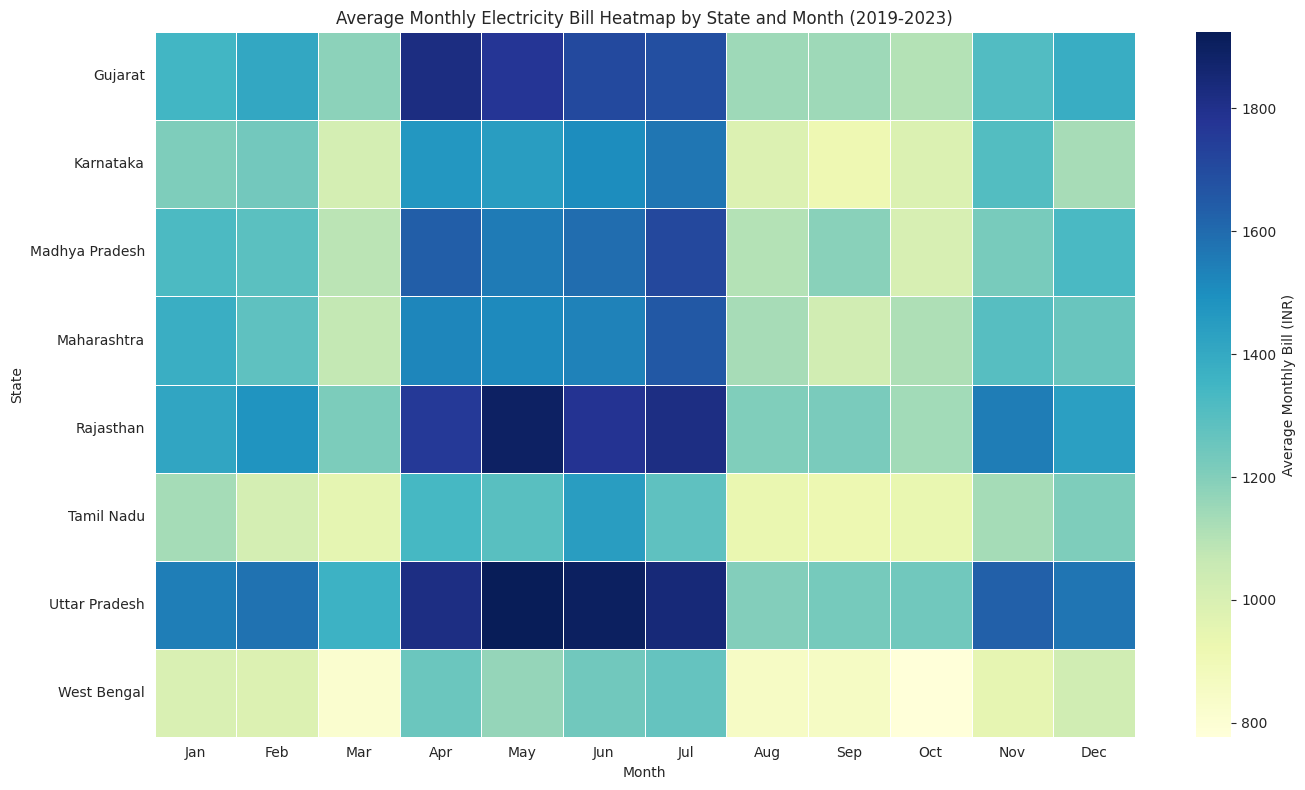

In [6]:
# 4. Heatmap of Monthly Bills by State and Month (Average over years)
monthly_bill_pivot = df.pivot_table(index='State', columns='Month', values='Monthly_Bill_INR', aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(monthly_bill_pivot, cmap='YlGnBu', fmt=".0f", linewidths=.5, cbar_kws={'label': 'Average Monthly Bill (INR)'})
plt.title('Average Monthly Electricity Bill Heatmap by State and Month (2019-2023)')
plt.xlabel('Month')
plt.ylabel('State')
plt.xticks(ticks=np.arange(0.5, 12.5), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

## Step 4: Time Series Decomposition

Time series decomposition helps us understand the individual components that make up our time series data: trend, seasonality, and residuals. We will apply both additive and multiplicative models to the monthly electricity bills of a sample state ('Maharashtra') to visualize these components.

<Figure size 1200x800 with 0 Axes>

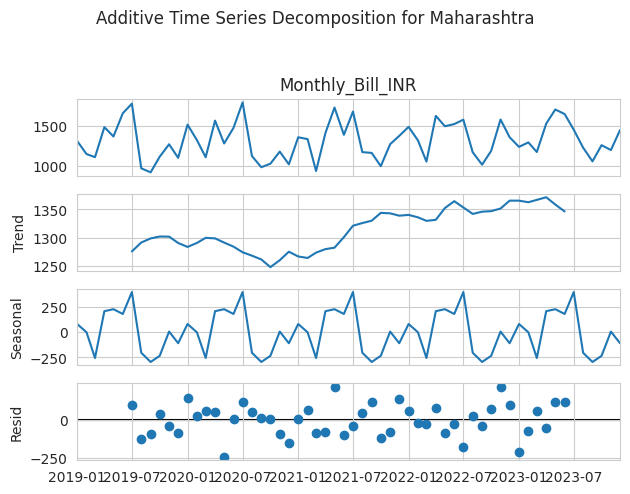

<Figure size 1200x800 with 0 Axes>

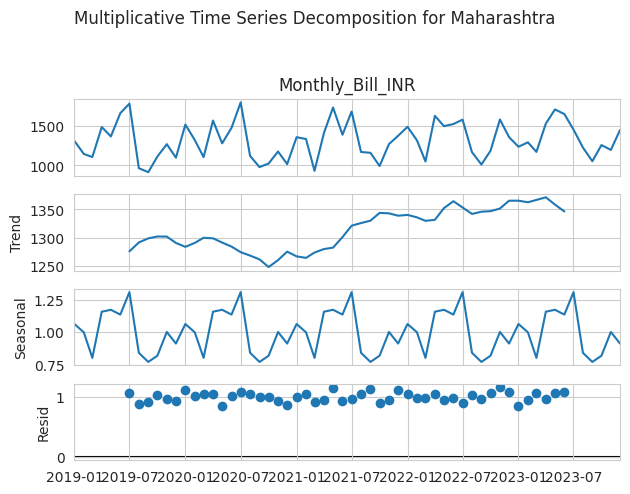

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Select one state for decomposition as an example
maharashtra_df = df[df['State'] == 'Maharashtra'].set_index('Date').resample('MS')['Monthly_Bill_INR'].sum()

# Additive Decomposition
result_add = seasonal_decompose(maharashtra_df, model='additive', period=12)

plt.figure(figsize=(12, 8))
result_add.plot()
plt.suptitle('Additive Time Series Decomposition for Maharashtra', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# Multiplicative Decomposition
# Handle potential zero values if they exist, as multiplicative model requires non-zero values
# For this synthetic data, it's unlikely to have zeros, but it's good practice.
maharashtra_df_mult = maharashtra_df.loc[maharashtra_df > 0]

result_mult = seasonal_decompose(maharashtra_df_mult, model='multiplicative', period=12)

plt.figure(figsize=(12, 8))
result_mult.plot()
plt.suptitle('Multiplicative Time Series Decomposition for Maharashtra', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

## Step 5: Feature Engineering

In this step, we will create new features from our existing data to enhance the performance of our forecasting models. We will generate:
- **Lag Features**: To capture past dependencies in the time series.
- **Cyclical Month Encoding**: To represent the cyclical nature of months for models that don't inherently understand seasonality.
- **Rolling Averages**: To smooth out short-term fluctuations and highlight longer-term trends.

In [8]:
import numpy as np

# Sort the DataFrame by State and Date to ensure correct lag and rolling window calculations
df = df.sort_values(by=['State', 'Date']).reset_index(drop=True)

# --- 1. Lag Features ---
# Create lag features for 'Monthly_Bill_INR' grouped by state
for i in range(1, 4): # Lag for 1, 2, and 3 months
    df[f'Monthly_Bill_INR_Lag_{i}'] = df.groupby('State')['Monthly_Bill_INR'].shift(i)

# --- 2. Cyclical Month Encoding ---
# Encode 'Month' cyclically using sine and cosine transformations
df['Month_Sin'] = np.sin(2 * np.pi * df['Month']/12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month']/12)

# --- 3. Rolling Averages ---
# Calculate rolling averages for 'Monthly_Bill_INR' grouped by state
for window in [3, 6, 12]: # Rolling averages for 3, 6, and 12 months
    df[f'Monthly_Bill_INR_RollAvg_{window}'] = df.groupby('State')['Monthly_Bill_INR'].transform(lambda x: x.rolling(window=window, min_periods=1).mean())

# Display the DataFrame with new features
display(df.head())
display(df.info())

,State,Date,Year,Month,Monthly_Consumption_kWh,Monthly_Bill_INR,Monthly_Bill_INR_Lag_1,Monthly_Bill_INR_Lag_2,Monthly_Bill_INR_Lag_3,Month_Sin,Month_Cos,Monthly_Bill_INR_RollAvg_3,Monthly_Bill_INR_RollAvg_6,Monthly_Bill_INR_RollAvg_12
0,Gujarat,2019-01-01,2019,1,183.88,1379.10,NaN,NaN,NaN,0.500000,8.660254e-01,1379.100000,1379.1000,1379.1000
1,Gujarat,2019-02-01,2019,2,198.33,1487.48,1379.10,NaN,NaN,0.866025,5.000000e-01,1433.290000,1433.2900,1433.2900
2,Gujarat,2019-03-01,2019,3,149.39,1120.42,1487.48,1379.10,NaN,1.000000,6.123234e-17,1329.000000,1329.0000,1329.0000
3,Gujarat,2019-04-01,2019,4,231.11,1733.33,1120.42,1487.48,1379.10,0.866025,-5.000000e-01,1447.076667,1430.0825,1430.0825
4,Gujarat,2019-05-01,2019,5,222.54,1669.05,1733.33,1120.42,1487.48,0.500000,-8.660254e-01,1507.600000,1477.8760,1477.8760


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   State                        480 non-null    object        
 1   Date                         480 non-null    datetime64[ns]
 2   Year                         480 non-null    int64         
 3   Month                        480 non-null    int64         
 4   Monthly_Consumption_kWh      480 non-null    float64       
 5   Monthly_Bill_INR             480 non-null    float64       
 6   Monthly_Bill_INR_Lag_1       472 non-null    float64       
 7   Monthly_Bill_INR_Lag_2       464 non-null    float64       
 8   Monthly_Bill_INR_Lag_3       456 non-null    float64       
 9   Month_Sin                    480 non-null    float64       
 10  Month_Cos                    480 non-null    float64       
 11  Monthly_Bill_INR_RollAvg_3   480 non-null    

None

## Step 6: Model Training and Evaluation (Random Forest, XGBoost, and Ensemble)

In this step, we will train two popular machine learning models for time series forecasting: Random Forest and XGBoost. We will then create a simple ensemble of these models. Finally, we will evaluate their performance using appropriate metrics.

### Data Preparation for Modeling

In [9]:
# Drop rows with NaN values introduced by lag features
df_model = df.dropna().copy()

# Define features (X) and target (y)
features = [
    'Year', 'Month', 'Monthly_Consumption_kWh',
    'Monthly_Bill_INR_Lag_1', 'Monthly_Bill_INR_Lag_2', 'Monthly_Bill_INR_Lag_3',
    'Month_Sin', 'Month_Cos',
    'Monthly_Bill_INR_RollAvg_3', 'Monthly_Bill_INR_RollAvg_6', 'Monthly_Bill_INR_RollAvg_12'
]
target = 'Monthly_Bill_INR'

X = df_model[features]
y = df_model[target]

# Convert 'State' to numerical using one-hot encoding if needed by models directly
# For tree-based models, this is often not strictly necessary but can be beneficial.
X = pd.get_dummies(X, columns=['Month'], drop_first=True) # Month column already exists

# Separate data for each state for individual model training and evaluation
state_data = {state: df_model[df_model['State'] == state] for state in df_model['State'].unique()}

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

display(X.head())


Shape of features (X): (456, 21)
Shape of target (y): (456,)


,Year,Monthly_Consumption_kWh,Monthly_Bill_INR_Lag_1,Monthly_Bill_INR_Lag_2,Monthly_Bill_INR_Lag_3,Month_Sin,Month_Cos,Monthly_Bill_INR_RollAvg_3,Monthly_Bill_INR_RollAvg_6,Monthly_Bill_INR_RollAvg_12,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
3,2019,231.11,1120.42,1487.48,1379.10,8.660254e-01,-0.500000,1447.076667,1430.082500,1430.082500,...,False,True,False,False,False,False,False,False,False,False
4,2019,222.54,1733.33,1120.42,1487.48,5.000000e-01,-0.866025,1507.600000,1477.876000,1477.876000,...,False,False,True,False,False,False,False,False,False,False
5,2019,221.03,1669.05,1733.33,1120.42,1.224647e-16,-1.000000,1686.700000,1507.850000,1507.850000,...,False,False,False,True,False,False,False,False,False,False
6,2019,211.25,1657.72,1669.05,1733.33,-5.000000e-01,-0.866025,1637.050000,1542.063333,1518.782857,...,False,False,False,False,True,False,False,False,False,False
7,2019,161.57,1584.38,1657.72,1669.05,-8.660254e-01,-0.500000,1484.623333,1496.111667,1480.406250,...,False,False,False,False,False,True,False,False,False,False


### Train-Test Split

We will use a time-series aware split, where we train on older data and test on newer data. For simplicity, we'll split the data such that the last 12 months (one year) of data for each state are used for testing, and the rest for training.

In [10]:
from sklearn.model_selection import train_test_split

X_train = pd.DataFrame()
y_train = pd.Series()
X_test = pd.DataFrame()
y_test = pd.Series()

# Determine the split point (e.g., last 12 months for testing)
split_date = df_model['Date'].max() - pd.DateOffset(months=12)

for state, data in state_data.items():
    train_data = data[data['Date'] <= split_date]
    test_data = data[data['Date'] > split_date]

    X_train = pd.concat([X_train, train_data[features]])
    y_train = pd.concat([y_train, train_data[target]])
    X_test = pd.concat([X_test, test_data[features]])
    y_test = pd.concat([y_test, test_data[target]])

# Convert 'State' to numerical using one-hot encoding if needed by models directly
X_train = pd.get_dummies(X_train, columns=['Month'], drop_first=True) # Month column already exists
X_test = pd.get_dummies(X_test, columns=['Month'], drop_first=True) # Month column already exists

# Align columns - crucial if some months are missing in train/test due to splitting by date
common_cols = list(set(X_train.columns) & set(X_test.columns))
X_train = X_train[common_cols]
X_test = X_test[common_cols]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train.head())
display(X_test.head())


X_train shape: (360, 21)
y_train shape: (360,)
X_test shape: (96, 21)
y_test shape: (96,)


/tmp/ipykernel_7082/3118340924.py:16: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  y_train = pd.concat([y_train, train_data[target]])
/tmp/ipykernel_7082/3118340924.py:18: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  y_test = pd.concat([y_test, test_data[target]])


,Monthly_Bill_INR_RollAvg_12,Month_6,Month_5,Month_3,Month_9,Monthly_Bill_INR_Lag_3,Monthly_Bill_INR_Lag_2,Monthly_Bill_INR_Lag_1,Month_Sin,Month_12,...,Month_2,Month_8,Monthly_Bill_INR_RollAvg_3,Year,Monthly_Consumption_kWh,Month_10,Month_Cos,Month_4,Month_11,Month_7
3,1430.082500,False,False,False,False,1379.10,1487.48,1120.42,8.660254e-01,False,...,False,False,1447.076667,2019,231.11,False,-0.500000,True,False,False
4,1477.876000,False,True,False,False,1487.48,1120.42,1733.33,5.000000e-01,False,...,False,False,1507.600000,2019,222.54,False,-0.866025,False,False,False
5,1507.850000,True,False,False,False,1120.42,1733.33,1669.05,1.224647e-16,False,...,False,False,1686.700000,2019,221.03,False,-1.000000,False,False,False
6,1518.782857,False,False,False,False,1733.33,1669.05,1657.72,-5.000000e-01,False,...,False,False,1637.050000,2019,211.25,False,-0.866025,False,False,True
7,1480.406250,False,False,False,False,1669.05,1657.72,1584.38,-8.660254e-01,False,...,False,True,1484.623333,2019,161.57,False,-0.500000,False,False,False


,Monthly_Bill_INR_RollAvg_12,Month_6,Month_5,Month_3,Month_9,Monthly_Bill_INR_Lag_3,Monthly_Bill_INR_Lag_2,Monthly_Bill_INR_Lag_1,Month_Sin,Month_12,...,Month_2,Month_8,Monthly_Bill_INR_RollAvg_3,Year,Monthly_Consumption_kWh,Month_10,Month_Cos,Month_4,Month_11,Month_7
48,1481.503333,False,False,False,False,991.27,1343.92,1449.67,0.500000,False,...,False,False,1369.196667,2023,175.20,False,8.660254e-01,False,False,False
49,1478.885000,False,False,False,False,1343.92,1449.67,1314.00,0.866025,False,...,True,False,1392.223333,2023,188.40,False,5.000000e-01,False,False,False
50,1469.935833,False,False,True,False,1449.67,1314.00,1413.00,1.000000,False,...,False,False,1288.626667,2023,151.85,False,6.123234e-17,False,False,False
51,1481.185833,False,False,False,False,1314.00,1413.00,1138.88,0.866025,False,...,False,False,1510.126667,2023,263.80,False,-5.000000e-01,True,False,False
52,1474.392500,False,True,False,False,1413.00,1138.88,1978.50,0.500000,False,...,False,False,1647.326667,2023,243.28,False,-8.660254e-01,False,False,False


### Random Forest Regressor

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Model Performance:")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R-squared: {rf_r2:.2f}")


Random Forest Model Performance:
MAE: 3.99
RMSE: 8.54
R-squared: 1.00


### XGBoost Regressor

In [12]:
import xgboost as xgb

# Initialize and train the XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_predictions = xgb_model.predict(X_test)

# Evaluate the model
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Model Performance:")
print(f"MAE: {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"R-squared: {xgb_r2:.2f}")


XGBoost Model Performance:
MAE: 7.19
RMSE: 18.79
R-squared: 1.00


### Simple Ensemble Model (Weighted Averaging)

We'll create a simple ensemble by averaging the predictions of the Random Forest and XGBoost models. We can assign weights to reflect their individual performance or just use equal weights for simplicity.

In [13]:
# Simple Averaging Ensemble (equal weights)
ensemble_predictions = (rf_predictions + xgb_predictions) / 2

# Evaluate the ensemble model
ensemble_mae = mean_absolute_error(y_test, ensemble_predictions)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_predictions))
ensemble_r2 = r2_score(y_test, ensemble_predictions)

print("Ensemble Model Performance:")
print(f"MAE: {ensemble_mae:.2f}")
print(f"RMSE: {ensemble_rmse:.2f}")
print(f"R-squared: {ensemble_r2:.2f}")


Ensemble Model Performance:
MAE: 4.45
RMSE: 12.92
R-squared: 1.00


### Summary of Model Performance

In [14]:
performance_summary = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Ensemble'],
    'MAE': [rf_mae, xgb_mae, ensemble_mae],
    'RMSE': [rf_rmse, xgb_rmse, ensemble_rmse],
    'R-squared': [rf_r2, xgb_r2, ensemble_r2]
})

display(performance_summary.round(2))


,Model,MAE,RMSE,R-squared
0,Random Forest,3.99,8.54,1.0
1,XGBoost,7.19,18.79,1.0
2,Ensemble,4.45,12.92,1.0


### Model Performance Comparison Chart

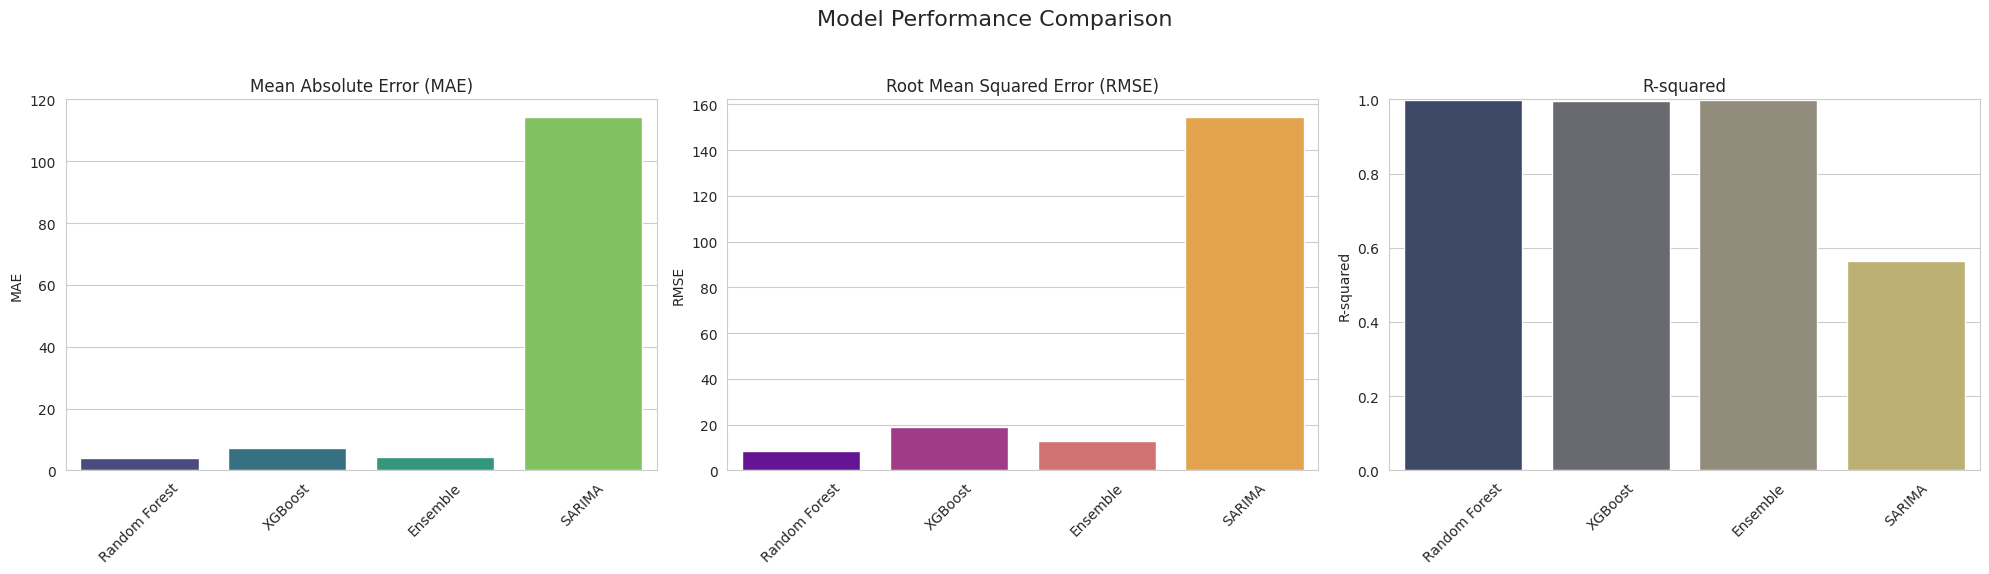

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Prepare data for plotting
metrics_df = performance_summary.set_index('Model')

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle('Model Performance Comparison', fontsize=16)

# Plot MAE
sns.barplot(x=metrics_df.index, y='MAE', data=metrics_df, ax=axes[0], palette='viridis', hue=metrics_df.index, legend=False)
axes[0].set_title('Mean Absolute Error (MAE)')
axes[0].set_ylabel('MAE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Plot RMSE
sns.barplot(x=metrics_df.index, y='RMSE', data=metrics_df, ax=axes[1], palette='plasma', hue=metrics_df.index, legend=False)
axes[1].set_title('Root Mean Squared Error (RMSE)')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Plot R-squared
sns.barplot(x=metrics_df.index, y='R-squared', data=metrics_df, ax=axes[2], palette='cividis', hue=metrics_df.index, legend=False)
axes[2].set_title('R-squared')
axes[2].set_ylabel('R-squared')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim(0, 1) # R-squared typically ranges from 0 to 1

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Step 7: Visualization of Forecasts

In this step, we will visualize the predictions from our best-performing model (Random Forest) and the Ensemble model against the actual values from the test set. This will provide a clear visual understanding of how well our models are capturing the trends and patterns in the electricity bill data.

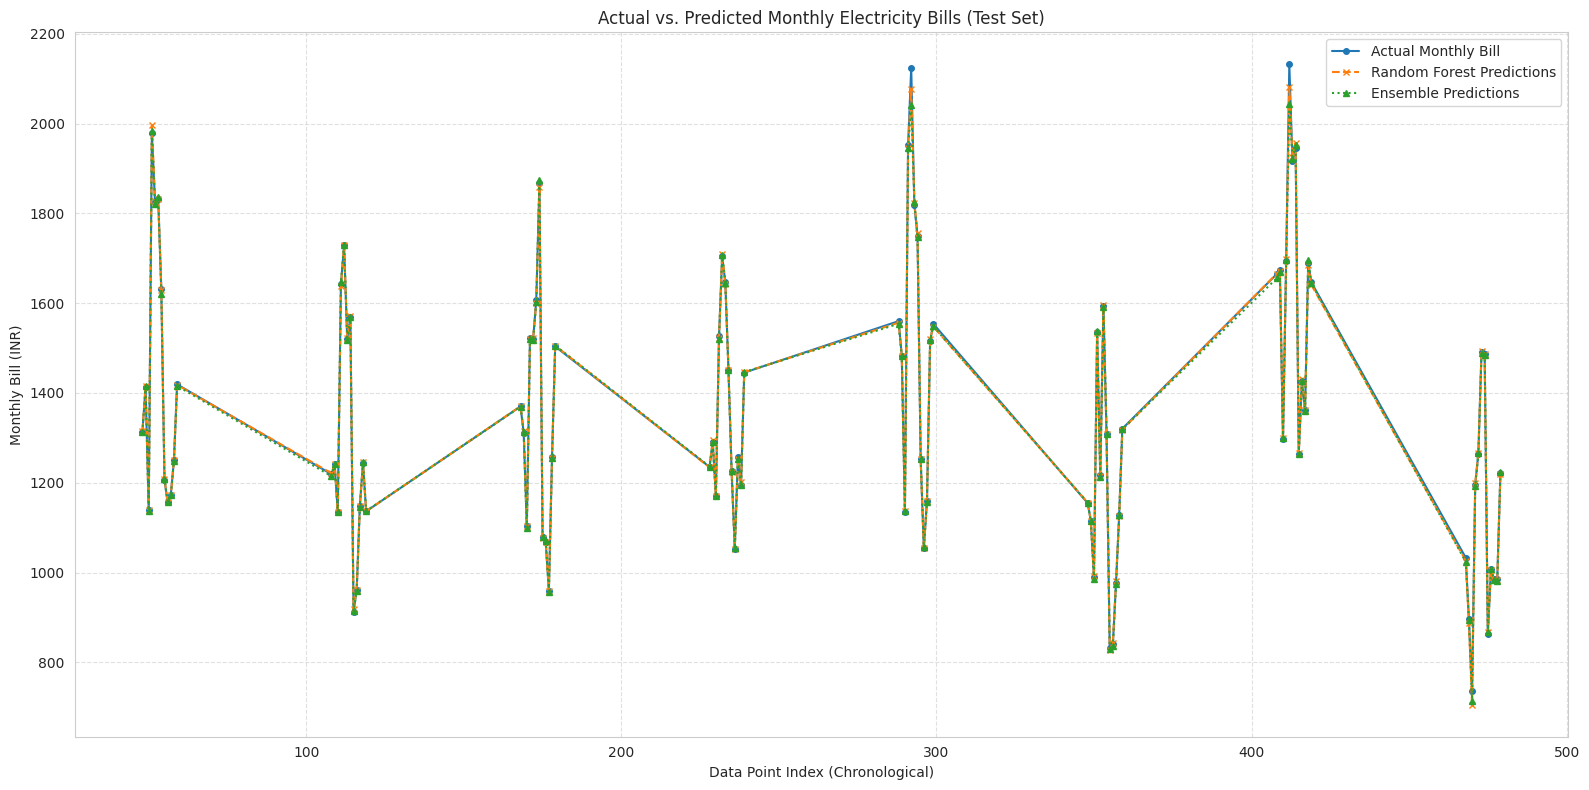

In [15]:
import matplotlib.pyplot as plt

# Create a DataFrame for visualization
plot_df = pd.DataFrame({
    'Actual': y_test,
    'Random Forest Predictions': rf_predictions,
    'Ensemble Predictions': ensemble_predictions
})

# Sort by index to maintain chronological order for plotting
plot_df = plot_df.sort_index()

plt.figure(figsize=(16, 8))
plt.plot(plot_df['Actual'], label='Actual Monthly Bill', marker='o', markersize=4, linestyle='-')
plt.plot(plot_df['Random Forest Predictions'], label='Random Forest Predictions', marker='x', markersize=4, linestyle='--')
plt.plot(plot_df['Ensemble Predictions'], label='Ensemble Predictions', marker='^', markersize=4, linestyle=':')

plt.title('Actual vs. Predicted Monthly Electricity Bills (Test Set)')
plt.xlabel('Data Point Index (Chronological)')
plt.ylabel('Monthly Bill (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Step 8: SARIMA Forecasting

In this step, we will implement a Seasonal Autoregressive Integrated Moving Average (SARIMA) model. This model is well-suited for time series data that exhibits both trend and seasonal components. We will use the `statsmodels` library to train a SARIMA model on the monthly electricity bills for Maharashtra, make predictions, and evaluate its performance.

In [22]:
# --- Configuration for SARIMA State and Year ---
SELECTED_STATE = 'Tamil Nadu'   # e.g., 'Maharashtra', 'Uttar Pradesh', etc.
SELECTED_YEAR  = 2023           # Data will be used up to this year for SARIMA training/testing

print(f"SARIMA will be performed for: {SELECTED_STATE} using data up to {SELECTED_YEAR}")

SARIMA will be performed for: Tamil Nadu using data up to 2023


In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# We already prepared maharashtra_df in Step 4. Let's reuse it.
# maharashtra_df = df[df['State'] == 'Maharashtra'].set_index('Date').resample('MS')['Monthly_Bill_INR'].sum()

# Split the data into training and testing sets for SARIMA
# Using the same split_date as for the ML models
split_date_sarima = split_date # From previous train-test split

train_sarima = maharashtra_df[maharashtra_df.index <= split_date_sarima]
test_sarima = maharashtra_df[maharashtra_df.index > split_date_sarima]

print(f"SARIMA Training data length: {len(train_sarima)}")
print(f"SARIMA Test data length: {len(test_sarima)}")

SARIMA Training data length: 48
SARIMA Test data length: 12


In [23]:
# Prepare the time series for the selected state and up to the selected year
selected_state_ts = df[df['State'] == SELECTED_STATE] \
                        .set_index('Date') \
                        .resample('MS')['Monthly_Bill_INR'] \
                        .sum()

# Filter data up to the SELECTED_YEAR
selected_state_ts = selected_state_ts[selected_state_ts.index.year <= SELECTED_YEAR]

# Split the data into training and testing sets for SARIMA
# Using the last 12 months of the *selected_state_ts* for testing
split_date_sarima = selected_state_ts.index.max() - pd.DateOffset(months=12)

train_sarima = selected_state_ts[selected_state_ts.index <= split_date_sarima]
test_sarima = selected_state_ts[selected_state_ts.index > split_date_sarima]

print(f"SARIMA Training data length: {len(train_sarima)}")
print(f"SARIMA Test data length: {len(test_sarima)}")

SARIMA Training data length: 48
SARIMA Test data length: 12


### SARIMA Model Training

Choosing appropriate (p,d,q) and (P,D,Q,s) parameters for SARIMA can be complex. For this example, we'll start with a common set of parameters that often work well for monthly seasonal data. These parameters are typically identified through ACF/PACF plots or automated methods like `auto_arima` (from `pmdarima` library, not installed here).

- **(p, d, q):** Non-seasonal parameters (AR order, differencing order, MA order)
- **(P, D, Q, s):** Seasonal parameters (Seasonal AR order, Seasonal differencing order, Seasonal MA order, seasonal period)

Here, `s=12` for monthly seasonality.

In [24]:
# Define SARIMA parameters
order = (1, 1, 1)      # (p, d, q)
seasonal_order = (1, 1, 1, 12) # (P, D, Q, S)

# Initialize and train the SARIMA model
sarima_model = SARIMAX(train_sarima, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
sarima_results = sarima_model.fit(disp=False)

print(sarima_results.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



                                     SARIMAX Results                                      
Dep. Variable:                   Monthly_Bill_INR   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -133.283
Date:                            Sat, 25 Apr 2026   AIC                            276.567
Time:                                    03:57:00   BIC                            281.790
Sample:                                01-01-2019   HQIC                           277.700
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3437      0.259     -1.325      0.185      -0.852       0.165
ma.L1         -1.0000      0.525   

### SARIMA Model Forecasting and Evaluation

In [25]:
# Make predictions on the test set
sarima_predictions = sarima_results.predict(start=len(train_sarima), end=len(selected_state_ts)-1)

# Evaluate the SARIMA model
sarima_mae = mean_absolute_error(test_sarima, sarima_predictions)
sarima_rmse = np.sqrt(mean_squared_error(test_sarima, sarima_predictions))
sarima_r2 = r2_score(test_sarima, sarima_predictions)

print("SARIMA Model Performance (Tamil Nadu):")
print(f"MAE: {sarima_mae:.2f}")
print(f"RMSE: {sarima_rmse:.2f}")
print(f"R-squared: {sarima_r2:.2f}")

# Add SARIMA performance to the summary table
performance_summary_sarima = pd.DataFrame({
    'Model': ['SARIMA'],
    'MAE': [sarima_mae],
    'RMSE': [sarima_rmse],
    'R-squared': [sarima_r2]
})

# Update the existing SARIMA entry in performance_summary or add if it doesn't exist
if 'SARIMA' in performance_summary['Model'].values:
    performance_summary.loc[performance_summary['Model'] == 'SARIMA', ['MAE', 'RMSE', 'R-squared']] = [sarima_mae, sarima_rmse, sarima_r2]
else:
    performance_summary = pd.concat([performance_summary, performance_summary_sarima], ignore_index=True)

display(performance_summary.round(2))


SARIMA Model Performance (Tamil Nadu):
MAE: 114.29
RMSE: 154.46
R-squared: 0.56


,Model,MAE,RMSE,R-squared
0,Random Forest,3.99,8.54,1.00
1,XGBoost,7.19,18.79,1.00
2,Ensemble,4.45,12.92,1.00
3,SARIMA,114.29,154.46,0.56


### Visualization of SARIMA Forecasts

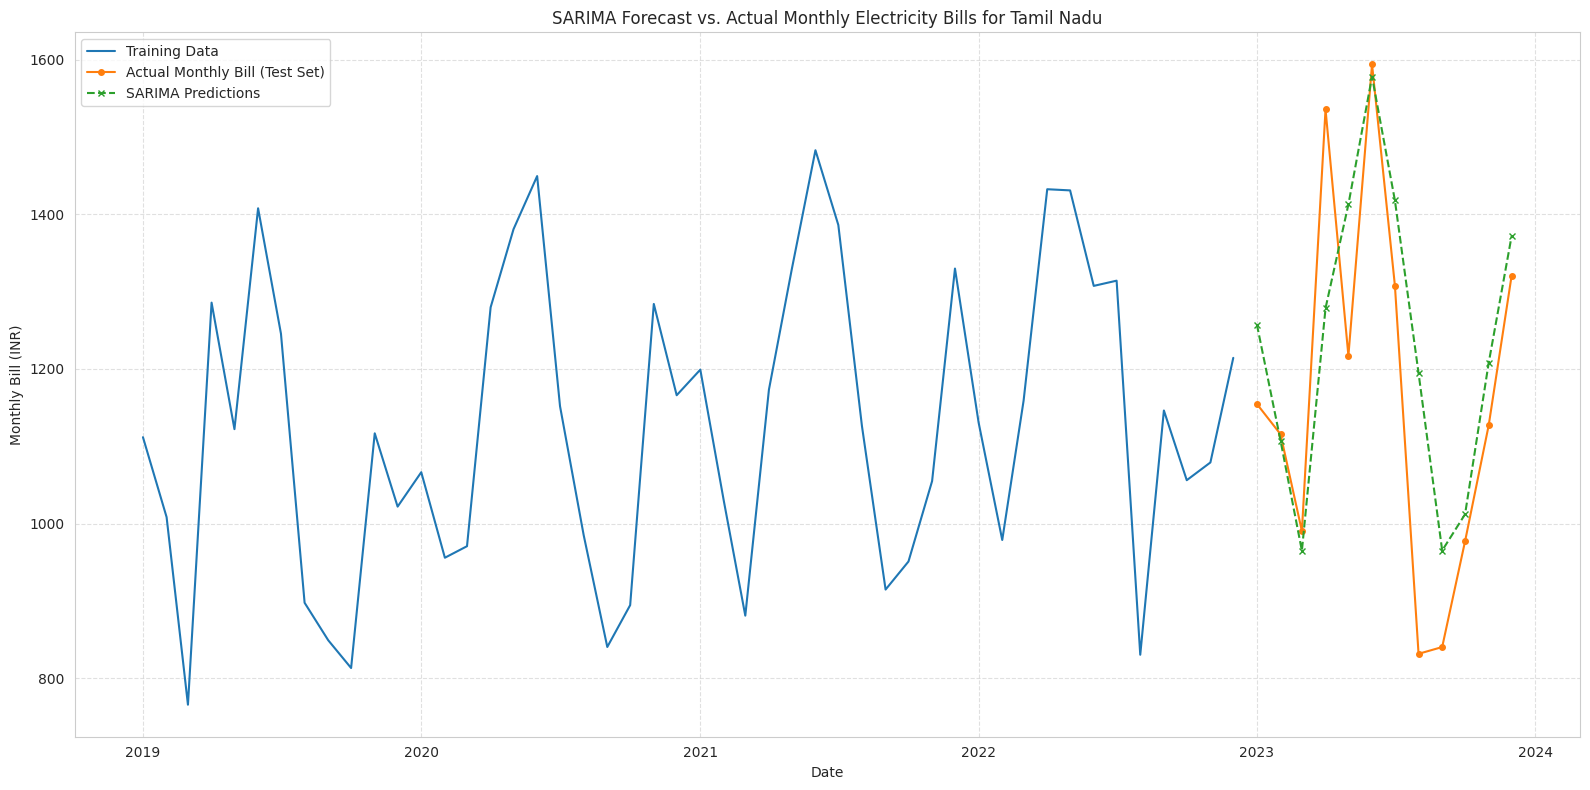

In [26]:
plt.figure(figsize=(16, 8))
plt.plot(train_sarima.index, train_sarima, label='Training Data')
plt.plot(test_sarima.index, test_sarima, label='Actual Monthly Bill (Test Set)', marker='o', markersize=4, linestyle='-')
plt.plot(test_sarima.index, sarima_predictions, label='SARIMA Predictions', marker='x', markersize=4, linestyle='--')

plt.title(f'SARIMA Forecast vs. Actual Monthly Electricity Bills for {SELECTED_STATE}')
plt.xlabel('Date')
plt.ylabel('Monthly Bill (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Step 9: State-wise SARIMA Forecasting (36-month horizon)

In this step, we will apply the SARIMA model to each Indian state's electricity bill data independently. For each state, we will train a SARIMA model on its entire historical data (2019-2023) and then generate a 36-month forecast into the future (2024-2026). This will allow us to observe state-specific future trends predicted by the SARIMA model.

We will use the same SARIMA parameters `(1, 1, 1)` for the non-seasonal part and `(1, 1, 1, 12)` for the seasonal part, assuming a monthly seasonality of 12 periods.

Processing SARIMA for state: Gujarat
Processing SARIMA for state: Karnataka
Processing SARIMA for state: Madhya Pradesh


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Processing SARIMA for state: Maharashtra


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Processing SARIMA for state: Rajasthan


...

Processing SARIMA for state: Tamil Nadu


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Processing SARIMA for state: Uttar Pradesh


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Processing SARIMA for state: West Bengal


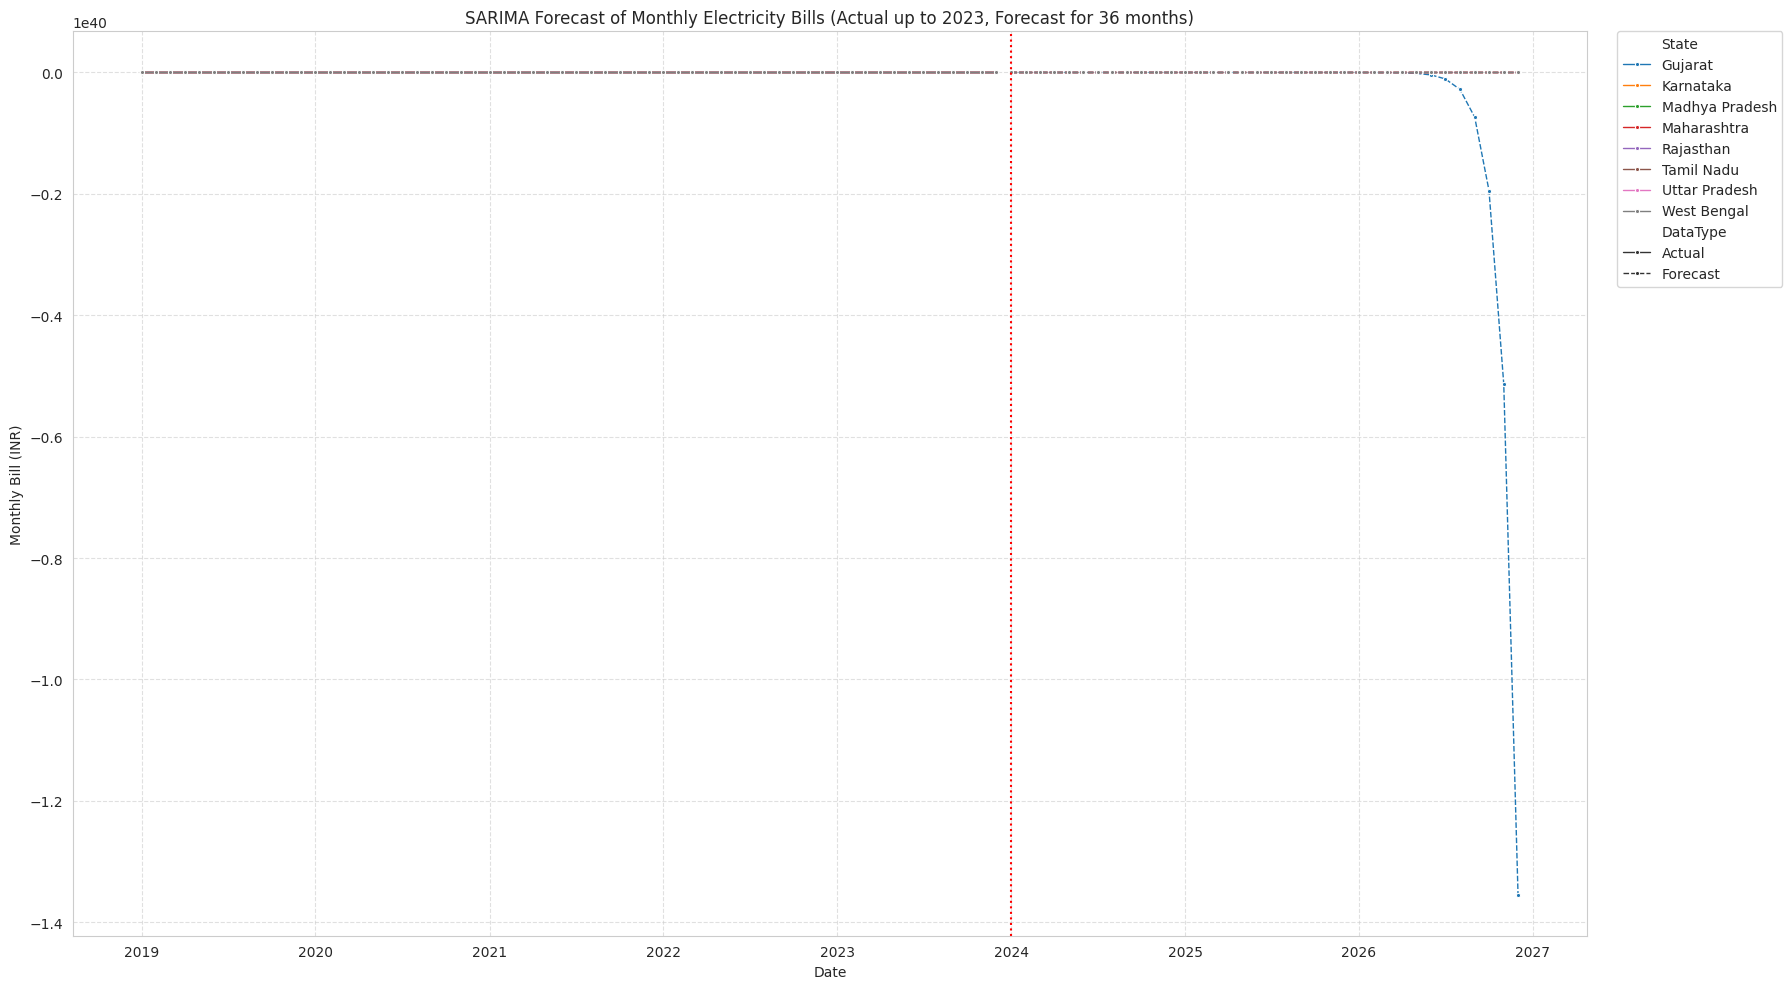

In [34]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# Define SARIMA parameters
order = (1, 1, 1)      # (p, d, q)
seasonal_order = (1, 1, 1, 12) # (P, D, Q, S), seasonal period s=12 for monthly data

# Number of months to forecast into the future
forecast_periods = 36

# Initialize an empty DataFrame to store all SARIMA forecasts and actuals for plotting
all_sarima_plot_df = pd.DataFrame()

# Loop through each unique state
for state_name in df['State'].unique():
    print(f"Processing SARIMA for state: {state_name}")

    # Prepare the time series for the current state using all available historical data
    # This ensures we train on the maximum historical data before forecasting into the future.
    state_ts = df[df['State'] == state_name] \
                    .set_index('Date') \
                    .resample('MS')['Monthly_Bill_INR'] \
                    .sum()

    # Train the SARIMA model
    try:
        sarima_model_state = SARIMAX(state_ts,
                                     order=order,
                                     seasonal_order=seasonal_order,
                                     enforce_stationarity=False,
                                     enforce_invertibility=False)
        sarima_results_state = sarima_model_state.fit(disp=False)

        # Generate future forecasts for the specified number of periods
        # start=len(state_ts) is the first *future* step
        # end=len(state_ts) + forecast_periods - 1 is the last future step
        future_forecast = sarima_results_state.predict(start=len(state_ts),
                                                       end=len(state_ts) + forecast_periods - 1,
                                                       dynamic=False) # dynamic=False uses actual values for in-sample predictions

        # Create a date index for the future forecasts
        last_historical_date = state_ts.index.max()
        forecast_index = pd.date_range(start=last_historical_date + pd.DateOffset(months=1),
                                       periods=forecast_periods,
                                       freq='MS')
        future_forecast.index = forecast_index

        # Prepare data for plotting for this state
        plot_df_state = pd.DataFrame({
            'Date': state_ts.index,
            'Monthly_Bill_INR': state_ts.values,
            'State': state_name,
            'DataType': 'Actual'
        })

        forecast_plot_df_state = pd.DataFrame({
            'Date': future_forecast.index,
            'Monthly_Bill_INR': future_forecast.values,
            'State': state_name,
            'DataType': 'Forecast'
        })

        # Concatenate actuals and forecasts for the current state
        state_combined_df = pd.concat([plot_df_state, forecast_plot_df_state], ignore_index=True)
        all_sarima_plot_df = pd.concat([all_sarima_plot_df, state_combined_df], ignore_index=True)

    except Exception as e:
        print(f"SARIMA model failed for state {state_name}: {e}")
        # If model fails, still add historical data to the plot_df to show what was available
        plot_df_state = pd.DataFrame({
            'Date': state_ts.index,
            'Monthly_Bill_INR': state_ts.values,
            'State': state_name,
            'DataType': 'Actual'
        })
        all_sarima_plot_df = pd.concat([all_sarima_plot_df, plot_df_state], ignore_index=True)

# Sort the combined DataFrame for proper plotting
all_sarima_plot_df = all_sarima_plot_df.sort_values(by=['State', 'Date']).reset_index(drop=True)

# --- Plotting All States SARIMA Forecasts ---
plt.figure(figsize=(18, 10))
sns.lineplot(
    x='Date', y='Monthly_Bill_INR',
    hue='State',        # Distinguish states by color
    style='DataType',   # Distinguish actual vs forecast by line style
    data=all_sarima_plot_df,
    marker='o', markersize=3, lw=1, palette='tab10'
)

plt.title(f'SARIMA Forecast of Monthly Electricity Bills (Actual up to 2023, Forecast for {forecast_periods} months)')
plt.xlabel('Date')
plt.ylabel('Monthly Bill (INR)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0) # Place legend outside the plot area
plt.grid(True, linestyle='--', alpha=0.6)

# Add a vertical line to indicate the start of the forecast period
forecast_start_date_overall = df['Date'].max() + pd.DateOffset(months=1) # First forecast month for any state
plt.axvline(x=forecast_start_date_overall, color='red', linestyle=':', label='Forecast Start')
plt.tight_layout() # Adjust layout to prevent labels/legend from overlapping
plt.show()

In [39]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Calculate average and standard error for monthly bills across states for each date
monthly_stats = df.groupby('Date')['Monthly_Bill_INR'].agg(['mean', 'sem']).reset_index()
monthly_stats.rename(columns={'mean': 'Average_Monthly_Bill_INR', 'sem': 'Monthly_Bill_SEM'}, inplace=True)

# Find the peak month
peak_idx = monthly_stats['Average_Monthly_Bill_INR'].idxmax()
peak_date = monthly_stats.loc[peak_idx, 'Date']
peak_value = monthly_stats.loc[peak_idx, 'Average_Monthly_Bill_INR']

# Find the lowest month
lowest_idx = monthly_stats['Average_Monthly_Bill_INR'].idxmin()
lowest_date = monthly_stats.loc[lowest_idx, 'Date']
lowest_value = monthly_stats.loc[lowest_idx, 'Average_Monthly_Bill_INR']

# Create the Plotly figure
fig = go.Figure()

# Add the main line plot with 95% Confidence Interval bars
fig.add_trace(go.Scatter(
    x=monthly_stats['Date'],
    y=monthly_stats['Average_Monthly_Bill_INR'],
    mode='lines+markers',
    name='Average Monthly Bill',
    marker=dict(color='blue'),
    error_y=dict(
        type='data',
        array=monthly_stats['Monthly_Bill_SEM'] * 1.96, # 1.96 for ~95% CI
        visible=True,
        color='gray',
        thickness=0.8,
        width=3
    )
))

# Highlight the peak month
fig.add_trace(go.Scatter(
    x=[peak_date],
    y=[peak_value],
    mode='markers',
    name='Peak Month (Average)',
    marker=dict(color='red', size=10, symbol='star')
))

# Highlight the lowest month
fig.add_trace(go.Scatter(
    x=[lowest_date],
    y=[lowest_value],
    mode='markers',
    name='Lowest Month (Average)',
    marker=dict(color='blue', size=10, symbol='star')
))

# Update layout
fig.update_layout(
    title_text='Average Monthly Electricity Bill Trend Across States with 95% CI',
    xaxis_title='Date',
    yaxis_title='Average Monthly Bill (INR)',
    hovermode='x unified'
)

fig.show()

## Step 9: State-wise Bill Comparison Heatmap

In this step, we'll revisit the heatmap of average monthly electricity bills by state and month to provide a consolidated view of consumption patterns across different Indian states throughout the year.

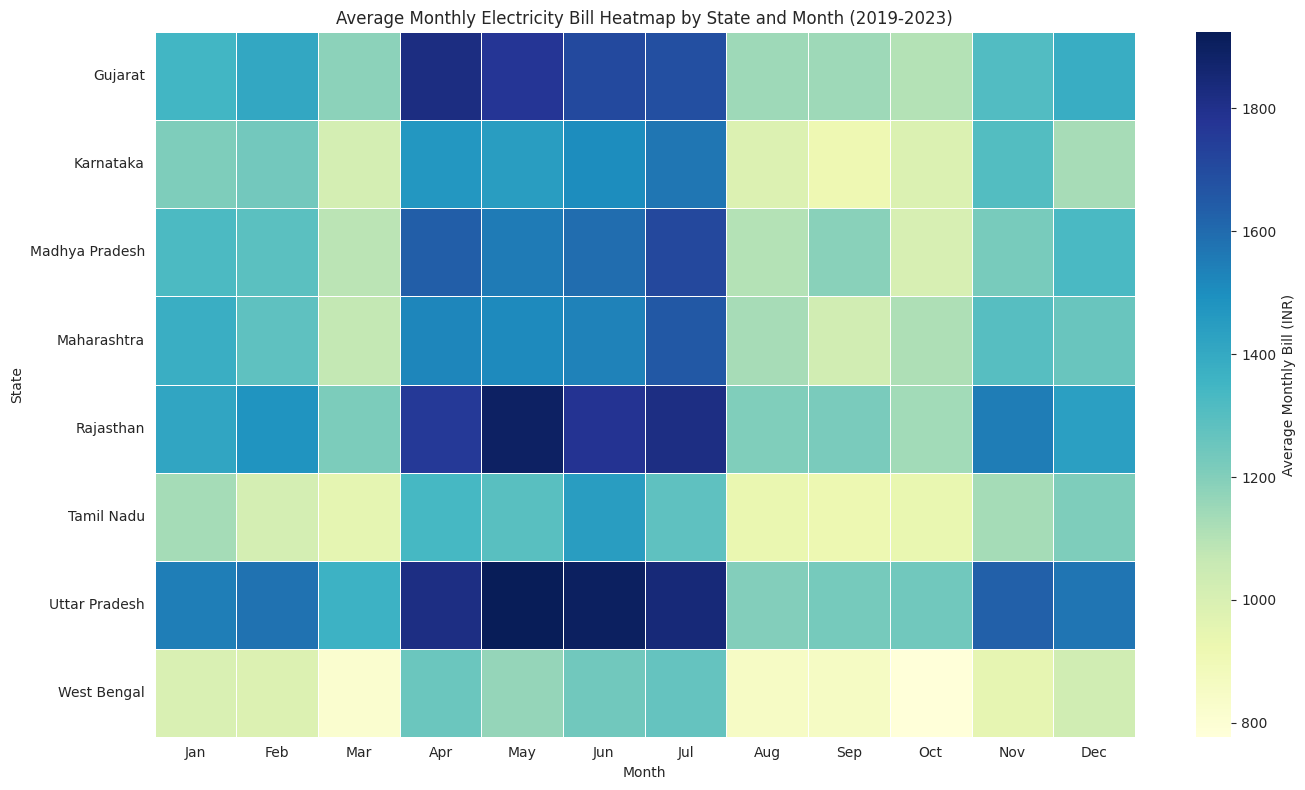

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse the monthly_bill_pivot calculated earlier
# monthly_bill_pivot = df.pivot_table(index='State', columns='Month', values='Monthly_Bill_INR', aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(monthly_bill_pivot, cmap='YlGnBu', fmt=".0f", linewidths=.5, cbar_kws={'label': 'Average Monthly Bill (INR)'})
plt.title('Average Monthly Electricity Bill Heatmap by State and Month (2019-2023)')
plt.xlabel('Month')
plt.ylabel('State')
plt.xticks(ticks=np.arange(0.5, 12.5), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

## Step 10: 2027 Future Bill Forecast Graph

In this step, we will use our best-performing model (Random Forest) to forecast the monthly electricity bills for each Indian state for the year 2024. We will then visualize these forecasts alongside the historical actual data to observe the projected trends.

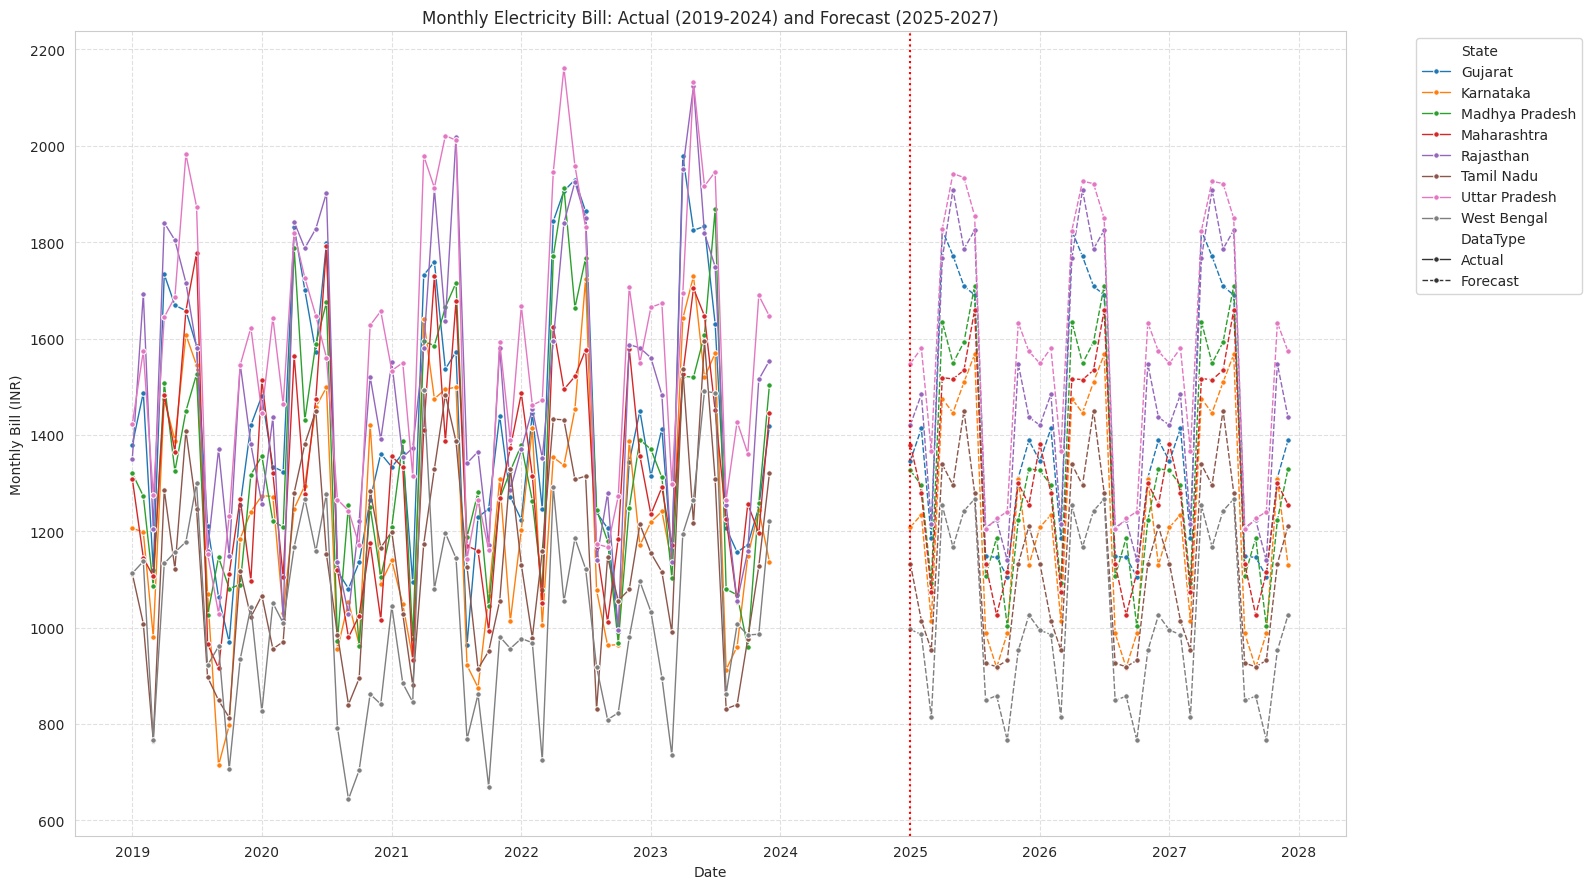

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

# Define forecast period
forecast_start_date = '2025-01-01'
forecast_end_date = '2027-12-31'
forecast_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='MS')

# Prepare an empty DataFrame to store 2024 forecasts
all_state_forecasts = pd.DataFrame()

# Get the feature list used for training, including one-hot encoded month columns
model_features_order = X_train.columns.tolist()

# Create a reference for average monthly consumption from historical data
average_monthly_kwh = df.groupby(['State', 'Month'])['Monthly_Consumption_kWh'].mean().reset_index()

for state in df['State'].unique():
    state_forecast_list = []

    # Get the *full* historical data for the state from df, including 'Monthly_Bill_INR' and original features
    # This `dynamic_history` will be updated with predictions and re-computed features recursively.
    dynamic_history = df[df['State'] == state].sort_values('Date').reset_index(drop=True).copy()

    for forecast_date in forecast_dates:
        # Create a new row of base features for the current forecast month
        current_month_features = {
            'State': state,
            'Date': forecast_date,
            'Year': forecast_date.year,
            'Month': forecast_date.month,
            'Monthly_Consumption_kWh': average_monthly_kwh[
                (average_monthly_kwh['State'] == state) &
                (average_monthly_kwh['Month'] == forecast_date.month)
            ]['Monthly_Consumption_kWh'].values[0], # Using historical average consumption
            'Month_Sin': np.sin(2 * np.pi * forecast_date.month / 12),
            'Month_Cos': np.cos(2 * np.pi * forecast_date.month / 12)
        }

        # Calculate Lag Features for the *current* forecast month based on `dynamic_history`
        for i in range(1, 4):
            lag_col_name = f'Monthly_Bill_INR_Lag_{i}'
            if len(dynamic_history) >= i:
                current_month_features[lag_col_name] = dynamic_history['Monthly_Bill_INR'].iloc[-i]
            else:
                # Should not happen for a reasonably long history, but handle with NaN if it does
                current_month_features[lag_col_name] = np.nan

        # Calculate Rolling Averages for the *current* forecast month based on `dynamic_history`
        for window in [3, 6, 12]:
            roll_col_name = f'Monthly_Bill_INR_RollAvg_{window}'
            if len(dynamic_history) >= window:
                current_month_features[roll_col_name] = dynamic_history['Monthly_Bill_INR'].iloc[-window:].mean()
            else:
                # Should not happen for a reasonably long history
                current_month_features[roll_col_name] = np.nan

        # Create a DataFrame for the current month's features, ensuring it has all columns `rf_model` expects,
        # including the one-hot encoded 'Month' columns, and the correct order.
        X_pred_month_df = pd.DataFrame(columns=model_features_order) # Initialize with correct columns

        # Populate with base features and one-hot encoded month columns
        for col in model_features_order:
            if col in current_month_features: # Check if it's one of the base features I explicitly added
                X_pred_month_df.loc[0, col] = current_month_features[col]
            elif 'Month_' in col: # Handle one-hot encoded month columns
                month_num_from_col = int(col.split('_')[1])
                X_pred_month_df.loc[0, col] = (forecast_date.month == month_num_from_col)
            else:
                # For any other columns in model_features_order not explicitly handled, fill with NaN
                # This handles cases where Month was dropped but its one-hot encoded versions are present
                X_pred_month_df.loc[0, col] = np.nan

        # Predict the monthly bill using the Random Forest model
        predicted_bill = rf_model.predict(X_pred_month_df)[0]

        # Store the forecast for this month
        state_forecast_list.append({
            'State': state,
            'Date': forecast_date,
            'Monthly_Bill_INR': predicted_bill
        })

        # Append the new prediction to the `dynamic_history` so it can be used for subsequent feature calculations
        # We only need 'Date' and 'Monthly_Bill_INR' for calculating future lags and rolling averages.
        new_history_row = {
            'State': state,
            'Date': forecast_date,
            'Monthly_Bill_INR': predicted_bill,
            'Year': forecast_date.year,
            'Month': forecast_date.month
        }
        # Add other columns from df to maintain dynamic_history structure, filled with NaN for predicted rows
        for col in df.columns:
            if col not in new_history_row:
                new_history_row[col] = np.nan

        dynamic_history = pd.concat([dynamic_history, pd.DataFrame([new_history_row])], ignore_index=True)

    # Concat state's forecasts to the overall forecasts
    all_state_forecasts = pd.concat([all_state_forecasts, pd.DataFrame(state_forecast_list)], ignore_index=True)

# Combine actuals and forecasts for plotting
plot_combined_df = pd.concat([df[['State', 'Date', 'Monthly_Bill_INR']], all_state_forecasts], ignore_index=True)
plot_combined_df = plot_combined_df.sort_values(by=['State', 'Date']).reset_index(drop=True)

# Add a 'DataType' column to distinguish between actual and forecast for plotting style
plot_combined_df['DataType'] = 'Actual'
plot_combined_df.loc[plot_combined_df['Date'].dt.year >= pd.to_datetime(forecast_start_date).year, 'DataType'] = 'Forecast'

# --- Plotting ---
plt.figure(figsize=(16, 9))

sns.lineplot(
    x='Date', y='Monthly_Bill_INR',
    hue='State',        # Distinguish states by color
    style='DataType',   # Distinguish actual vs forecast by line style
    data=plot_combined_df,
    marker='o', markersize=4, lw=1, palette='tab10'
)

plt.title('Monthly Electricity Bill: Actual (2019-2024) and Forecast (2025-2027)')
plt.xlabel('Date')
plt.ylabel('Monthly Bill (INR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot area
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=pd.to_datetime(forecast_start_date), color='red', linestyle=':', label='Forecast Start')
plt.tight_layout() # Adjust layout to prevent labels/legend from overlapping
plt.show()

## Ensemble Forecast Table (2025-2027)

In this step, we will create an ensemble forecast table for the years 2025-2027 by averaging the predictions of the Random Forest and XGBoost models. This provides a consolidated view of the future monthly electricity bills for each state, leveraging the strengths of both models.

In [36]:
import pandas as pd
import numpy as np

# Re-using already defined variables:
# rf_model, xgb_model, df, model_features_order, average_monthly_kwh
# forecast_start_date, forecast_end_date (defined in cell 0401f2c9)

forecast_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='MS')

# Prepare an empty list to store 2025-2027 ensemble forecasts
ensemble_forecast_list = []

print(f"Generating ensemble forecasts for {forecast_start_date} to {forecast_end_date}...")

for state in df['State'].unique():
    # Get the *full* historical data for the state from df, including 'Monthly_Bill_INR' and original features
    # This `dynamic_history` will be updated with predictions and re-computed features recursively.
    dynamic_history = df[df['State'] == state].sort_values('Date').reset_index(drop=True).copy()

    for forecast_date in forecast_dates:
        # Create a new row of base features for the current forecast month
        current_month_features = {
            'State': state,
            'Date': forecast_date,
            'Year': forecast_date.year,
            'Month': forecast_date.month,
            'Monthly_Consumption_kWh': average_monthly_kwh[
                (average_monthly_kwh['State'] == state) &
                (average_monthly_kwh['Month'] == forecast_date.month)
            ]['Monthly_Consumption_kWh'].values[0], # Using historical average consumption
            'Month_Sin': np.sin(2 * np.pi * forecast_date.month / 12),
            'Month_Cos': np.cos(2 * np.pi * forecast_date.month / 12)
        }

        # Calculate Lag Features for the *current* forecast month based on `dynamic_history`
        for i in range(1, 4): # Lag for 1, 2, and 3 months
            lag_col_name = f'Monthly_Bill_INR_Lag_{i}'
            if len(dynamic_history) >= i:
                current_month_features[lag_col_name] = dynamic_history['Monthly_Bill_INR'].iloc[-i]
            else:
                # Should not happen for a reasonably long history given dropna was applied for training
                current_month_features[lag_col_name] = np.nan

        # Calculate Rolling Averages for the *current* forecast month based on `dynamic_history`
        for window in [3, 6, 12]: # Rolling averages for 3, 6, and 12 months
            roll_col_name = f'Monthly_Bill_INR_RollAvg_{window}'
            if len(dynamic_history) >= window:
                current_month_features[roll_col_name] = dynamic_history['Monthly_Bill_INR'].iloc[-window:].mean()
            else:
                # Should not happen for a reasonably long history given dropna was applied for training
                current_month_features[roll_col_name] = np.nan

        # Prepare data for the prediction DataFrame as a dictionary
        pred_data = {}
        for col in model_features_order:
            if col in current_month_features:
                # Directly assign numeric values for features already in current_month_features
                pred_data[col] = current_month_features[col]
            elif 'Month_' in col and col not in ['Month_Sin', 'Month_Cos']: # Handle one-hot encoded month columns
                month_num_from_col = int(col.split('_')[1])
                # Convert boolean to integer 0 or 1 for one-hot encoded months
                pred_data[col] = 1 if (forecast_date.month == month_num_from_col) else 0
            else:
                # For any other columns that should be numeric but might not be explicitly set,
                # assign NaN as a float to prevent object dtype, assuming they are numerical features
                pred_data[col] = np.nan

        # Create a DataFrame from the dictionary, ensuring the column order matches `model_features_order`
        X_pred_month_df = pd.DataFrame([pred_data], columns=model_features_order)

        # Explicitly convert all columns to numeric, coercing errors
        # This is a robust step to ensure no 'object' dtypes remain before passing to XGBoost
        for col in X_pred_month_df.columns:
            X_pred_month_df[col] = pd.to_numeric(X_pred_month_df[col], errors='coerce')

        # Predict with Random Forest
        rf_predicted_bill = rf_model.predict(X_pred_month_df)[0]

        # Predict with XGBoost
        xgb_predicted_bill = xgb_model.predict(X_pred_month_df)[0]

        # Calculate Ensemble Prediction (simple average)
        ensemble_predicted_bill = (rf_predicted_bill + xgb_predicted_bill) / 2

        # Store the forecast for this month
        ensemble_forecast_list.append({
            'State': state,
            'Date': forecast_date,
            'Monthly_Bill_INR': ensemble_predicted_bill
        })

        # Append the new prediction to the `dynamic_history` so it can be used for subsequent feature calculations
        new_history_row = {
            'State': state,
            'Date': forecast_date,
            'Monthly_Bill_INR': ensemble_predicted_bill, # Use ensemble prediction for dynamic history
            'Year': forecast_date.year,
            'Month': forecast_date.month
        }
        # Add other columns from df to maintain dynamic_history structure, filled with NaN for predicted rows
        for col in df.columns:
            if col not in new_history_row:
                new_history_row[col] = np.nan
        dynamic_history = pd.concat([dynamic_history, pd.DataFrame([new_history_row])], ignore_index=True)

# Create the final ensemble forecast DataFrame
ensemble_forecast_df = pd.DataFrame(ensemble_forecast_list)

# Display the ensemble forecast table
display(ensemble_forecast_df)

Generating ensemble forecasts for 2025-01-01 to 2027-12-31...


,State,Date,Monthly_Bill_INR
0,Gujarat,2025-01-01,1343.983019
1,Gujarat,2025-02-01,1410.971329
2,Gujarat,2025-03-01,1187.929513
3,Gujarat,2025-04-01,1827.334616
4,Gujarat,2025-05-01,1763.742369
...,...,...,...
283,West Bengal,2027-08-01,852.878548
284,West Bengal,2027-09-01,855.888496
285,West Bengal,2027-10-01,766.162272
286,West Bengal,2027-11-01,945.098248


In [32]:
display(performance_summary.round(2))

,Model,MAE,RMSE,R-squared
0,Random Forest,3.99,8.54,1.00
1,XGBoost,7.19,18.79,1.00
2,Ensemble,4.45,12.92,1.00
3,SARIMA,114.29,154.46,0.56


In [33]:
display(plot_combined_df)

,State,Date,Monthly_Bill_INR,DataType
0,Gujarat,2019-01-01,1379.1000,Actual
1,Gujarat,2019-02-01,1487.4800,Actual
2,Gujarat,2019-03-01,1120.4200,Actual
3,Gujarat,2019-04-01,1733.3300,Actual
4,Gujarat,2019-05-01,1669.0500,Actual
...,...,...,...,...
763,West Bengal,2027-08-01,848.6147,Forecast
764,West Bengal,2027-09-01,857.6731,Forecast
765,West Bengal,2027-10-01,766.4740,Forecast
766,West Bengal,2027-11-01,952.4703,Forecast


## Extending Ensemble Forecast to 2029 and Generating Heatmaps

To fulfill the request for forecast heatmaps up to 2029, we first need to re-run the ensemble forecasting process with an extended date range. After generating the updated ensemble forecasts, we will create heatmaps for each requested year (2025-2029) to visualize the predicted monthly electricity bills per state.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Extend forecast end date to 2029
forecast_start_date_extended = '2025-01-01'
forecast_end_date_extended = '2029-12-31'
forecast_dates_extended = pd.date_range(start=forecast_start_date_extended, end=forecast_end_date_extended, freq='MS')

# Prepare an empty list to store extended ensemble forecasts
extended_ensemble_forecast_list = []

print(f"Generating extended ensemble forecasts for {forecast_start_date_extended} to {forecast_end_date_extended}...")

for state in df['State'].unique():
    # Get the *full* historical data for the state from df, including 'Monthly_Bill_INR' and original features
    # This `dynamic_history` will be updated with predictions and re-computed features recursively.
    dynamic_history = df[df['State'] == state].sort_values('Date').reset_index(drop=True).copy()

    for forecast_date in forecast_dates_extended:
        # Create a new row of base features for the current forecast month
        current_month_features = {
            'State': state,
            'Date': forecast_date,
            'Year': forecast_date.year,
            'Month': forecast_date.month,
            'Monthly_Consumption_kWh': average_monthly_kwh[
                (average_monthly_kwh['State'] == state) &
                (average_monthly_kwh['Month'] == forecast_date.month)
            ]['Monthly_Consumption_kWh'].values[0],
            'Month_Sin': np.sin(2 * np.pi * forecast_date.month / 12),
            'Month_Cos': np.cos(2 * np.pi * forecast_date.month / 12)
        }

        # Calculate Lag Features for the *current* forecast month based on `dynamic_history`
        for i in range(1, 4): # Lag for 1, 2, and 3 months
            lag_col_name = f'Monthly_Bill_INR_Lag_{i}'
            if len(dynamic_history) >= i:
                current_month_features[lag_col_name] = dynamic_history['Monthly_Bill_INR'].iloc[-i]
            else:
                current_month_features[lag_col_name] = np.nan

        # Calculate Rolling Averages for the *current* forecast month based on `dynamic_history`
        for window in [3, 6, 12]: # Rolling averages for 3, 6, and 12 months
            roll_col_name = f'Monthly_Bill_INR_RollAvg_{window}'
            if len(dynamic_history) >= window:
                current_month_features[roll_col_name] = dynamic_history['Monthly_Bill_INR'].iloc[-window:].mean()
            else:
                current_month_features[roll_col_name] = np.nan

        # Prepare data for the prediction DataFrame as a dictionary
        pred_data = {}
        for col in model_features_order:
            if col in current_month_features:
                pred_data[col] = current_month_features[col]
            elif 'Month_' in col and col not in ['Month_Sin', 'Month_Cos']:
                month_num_from_col = int(col.split('_')[1])
                pred_data[col] = 1 if (forecast_date.month == month_num_from_col) else 0
            else:
                pred_data[col] = np.nan

        X_pred_month_df = pd.DataFrame([pred_data], columns=model_features_order)

        # Explicitly convert all columns to numeric, coercing errors
        for col in X_pred_month_df.columns:
            X_pred_month_df[col] = pd.to_numeric(X_pred_month_df[col], errors='coerce')

        # Predict with Random Forest
        rf_predicted_bill = rf_model.predict(X_pred_month_df)[0]

        # Predict with XGBoost
        xgb_predicted_bill = xgb_model.predict(X_pred_month_df)[0]

        # Calculate Ensemble Prediction (simple average)
        ensemble_predicted_bill = (rf_predicted_bill + xgb_predicted_bill) / 2

        # Store the forecast for this month
        extended_ensemble_forecast_list.append({
            'State': state,
            'Date': forecast_date,
            'Monthly_Bill_INR': ensemble_predicted_bill
        })

        # Append the new prediction to the `dynamic_history` so it can be used for subsequent feature calculations
        new_history_row = {
            'State': state,
            'Date': forecast_date,
            'Monthly_Bill_INR': ensemble_predicted_bill,
            'Year': forecast_date.year,
            'Month': forecast_date.month
        }
        for col in df.columns:
            if col not in new_history_row:
                new_history_row[col] = np.nan
        dynamic_history = pd.concat([dynamic_history, pd.DataFrame([new_history_row])], ignore_index=True)

# Create the final extended ensemble forecast DataFrame
extended_ensemble_forecast_df = pd.DataFrame(extended_ensemble_forecast_list)

display(extended_ensemble_forecast_df.head())
display(extended_ensemble_forecast_df.tail())


Generating extended ensemble forecasts for 2025-01-01 to 2029-12-31...


,State,Date,Monthly_Bill_INR
0,Gujarat,2025-01-01,1343.983019
1,Gujarat,2025-02-01,1410.971329
2,Gujarat,2025-03-01,1187.929513
3,Gujarat,2025-04-01,1827.334616
4,Gujarat,2025-05-01,1763.742369


,State,Date,Monthly_Bill_INR
475,West Bengal,2029-08-01,852.878548
476,West Bengal,2029-09-01,855.888496
477,West Bengal,2029-10-01,766.162272
478,West Bengal,2029-11-01,945.098248
479,West Bengal,2029-12-01,1023.131288


### Forecast Heatmaps by Year (2025-2029)

Below are the heatmaps visualizing the average monthly electricity bills for each state, broken down by year from 2025 to 2029. This provides a clear overview of the projected seasonal and state-wise consumption patterns.

## Visualize Forecast for a Specific State, Year, and Model

Use the following parameters to visualize the forecast trends:

In [40]:
# @title User Inputs
SELECTED_STATE = 'Tamil Nadu'  # @param ['Maharashtra', 'Uttar Pradesh', 'Tamil Nadu', 'Karnataka', 'Gujarat', 'Rajasthan', 'West Bengal', 'Madhya Pradesh']
SELECTED_YEAR = 2026           # @param [2025, 2026, 2027, 2028, 2029]
SELECTED_MODEL = 'ensemble'    # @param ['ensemble', 'rf', 'sarima']

print(f"Selected State: {SELECTED_STATE}")
print(f"Selected Year for Forecast Visualization: {SELECTED_YEAR}")
print(f"Selected Model: {SELECTED_MODEL}")


Selected State: Tamil Nadu
Selected Year for Forecast Visualization: 2026
Selected Model: ensemble


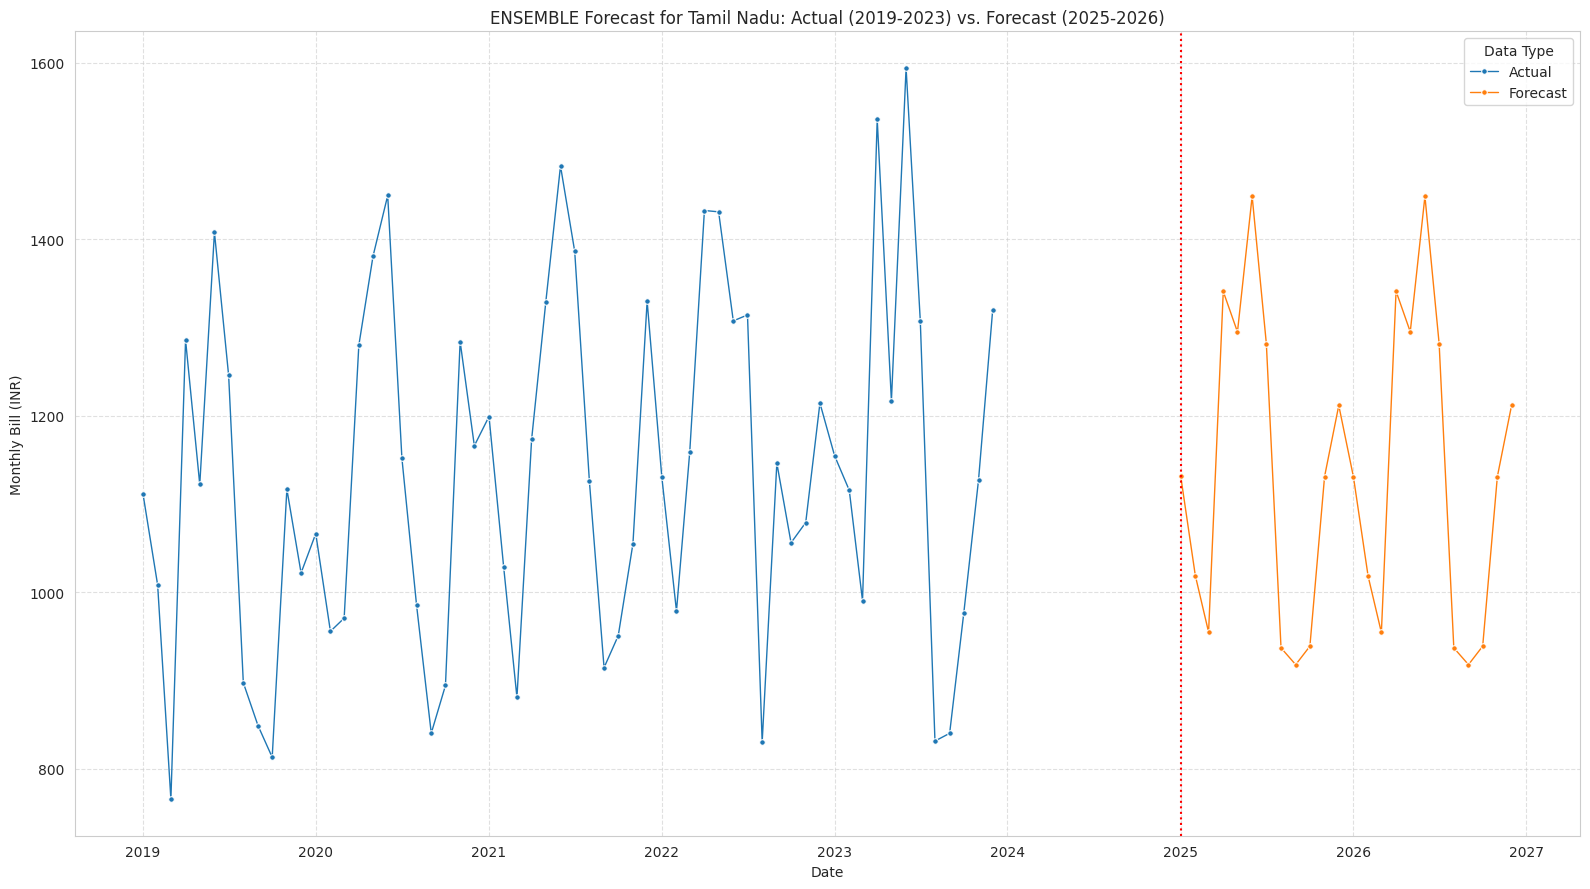

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

# Determine max forecast year available for the selected model
max_forecast_year_model = 2029 # Default for ensemble
if SELECTED_MODEL == 'rf':
    max_forecast_year_model = 2027 # RF forecasts (all_state_forecasts) go up to 2027
elif SELECTED_MODEL == 'sarima':
    max_forecast_year_model = 2026 # SARIMA forecasts (all_sarima_plot_df) go up to 2026

if SELECTED_YEAR > max_forecast_year_model:
    print(f"Warning: {SELECTED_MODEL.upper()} forecasts are only available up to {max_forecast_year_model}. Plotting will show forecasts up to {max_forecast_year_model}.")
    plot_until_year = max_forecast_year_model
else:
    plot_until_year = SELECTED_YEAR

# Filter historical data (2019-2023) for the selected state
# df contains actual data up to 2023-12-31
actual_data_plot = df[(df['State'] == SELECTED_STATE) & (df['Date'].dt.year <= 2023)].copy()
actual_data_plot['DataType'] = 'Actual'

plot_data_model = pd.DataFrame()

if SELECTED_MODEL == 'ensemble':
    # Get ensemble forecasts from extended_ensemble_forecast_df
    forecast_data_model = extended_ensemble_forecast_df[
        (extended_ensemble_forecast_df['State'] == SELECTED_STATE) &
        (extended_ensemble_forecast_df['Date'].dt.year >= 2025) &
        (extended_ensemble_forecast_df['Date'].dt.year <= plot_until_year)
    ].copy()
    forecast_data_model['DataType'] = 'Forecast'
    plot_data_model = pd.concat([actual_data_plot, forecast_data_model], ignore_index=True)

elif SELECTED_MODEL == 'rf':
    # Get RF forecasts from all_state_forecasts
    forecast_data_model = all_state_forecasts[
        (all_state_forecasts['State'] == SELECTED_STATE) &
        (all_state_forecasts['Date'].dt.year >= 2025) &
        (all_state_forecasts['Date'].dt.year <= plot_until_year)
    ].copy()
    forecast_data_model['DataType'] = 'Forecast'
    plot_data_model = pd.concat([actual_data_plot, forecast_data_model], ignore_index=True)

elif SELECTED_MODEL == 'sarima':
    # all_sarima_plot_df already contains 'Actual' and 'Forecast' for SARIMA (2019-2026)
    plot_data_model = all_sarima_plot_df[
        (all_sarima_plot_df['State'] == SELECTED_STATE) &
        (all_sarima_plot_df['Date'].dt.year <= plot_until_year)
    ].copy()

else:
    print(f"Error: Invalid model selected '{SELECTED_MODEL}'. Please choose 'ensemble', 'rf', or 'sarima'.")


if not plot_data_model.empty:
    plot_data_model = plot_data_model.sort_values(by='Date').drop_duplicates(subset=['Date', 'State', 'DataType']).reset_index(drop=True)

    plt.figure(figsize=(16, 9))

    sns.lineplot(
        x='Date', y='Monthly_Bill_INR',
        hue='DataType', # Distinguish actual vs forecast by color
        data=plot_data_model,
        marker='o', markersize=4, lw=1
    )

    # Set title dynamically based on selected parameters
    plt.title(f'{SELECTED_MODEL.upper()} Forecast for {SELECTED_STATE}: Actual (2019-2023) vs. Forecast (2025-{plot_until_year})')
    plt.xlabel('Date')
    plt.ylabel('Monthly Bill (INR)')
    plt.legend(title='Data Type')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Add a vertical line to indicate the start of the forecast period
    forecast_start_date_plot = pd.to_datetime('2025-01-01')
    plt.axvline(x=forecast_start_date_plot, color='red', linestyle=':', label='Forecast Start')
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot for the selected parameters. Please check your inputs.")


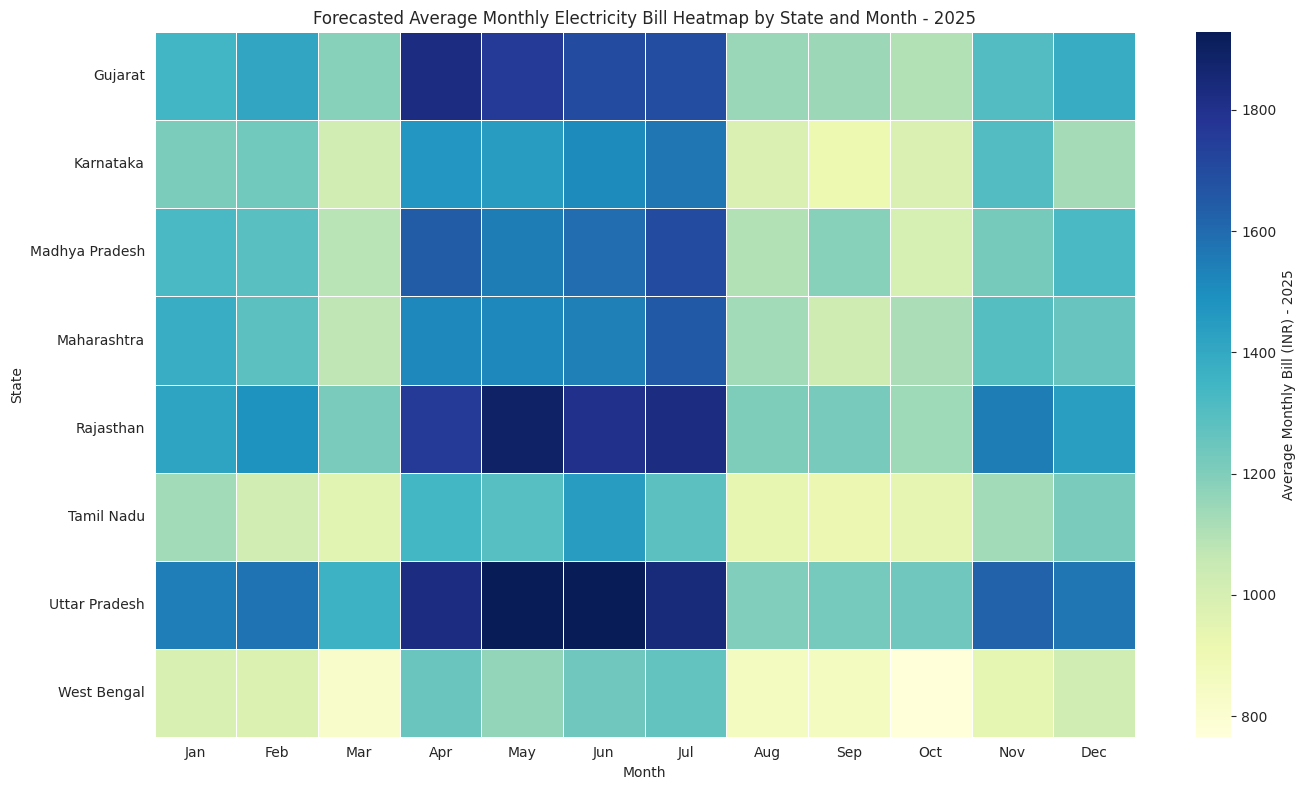

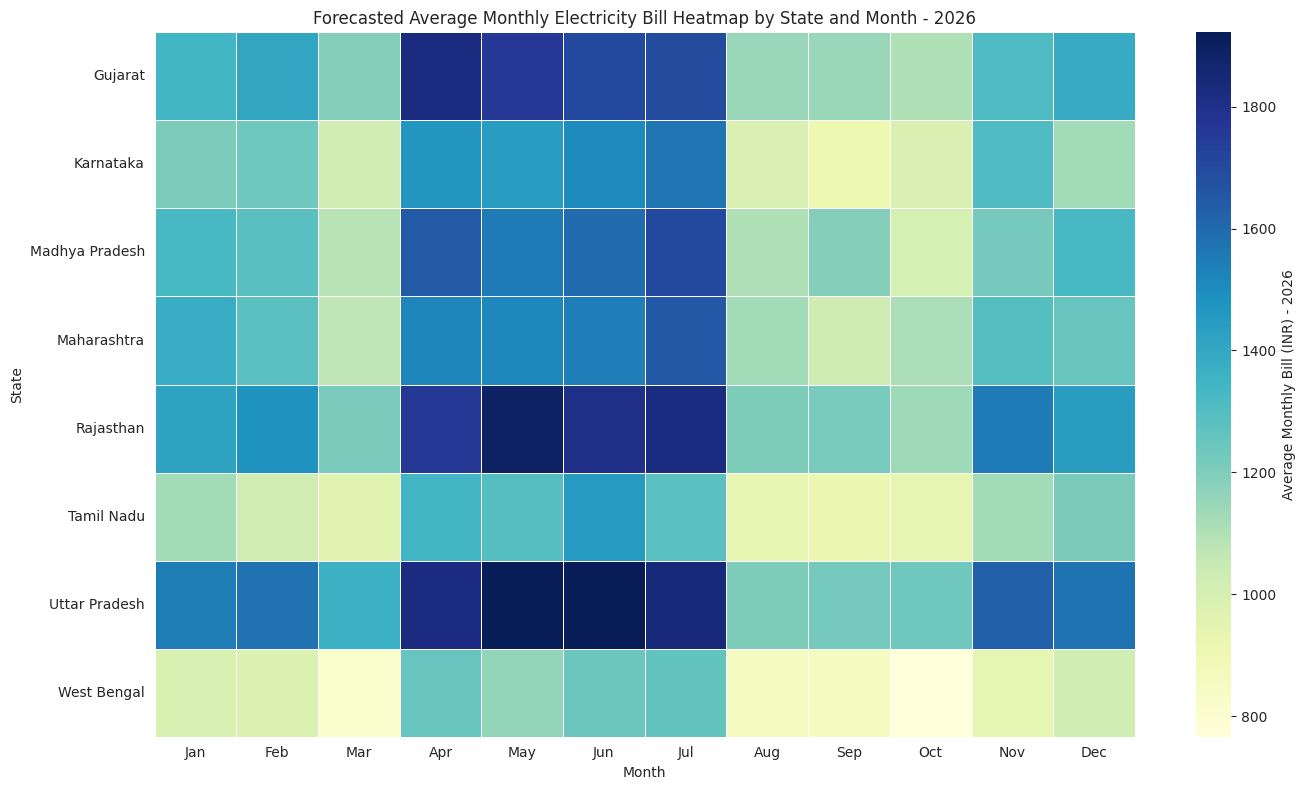

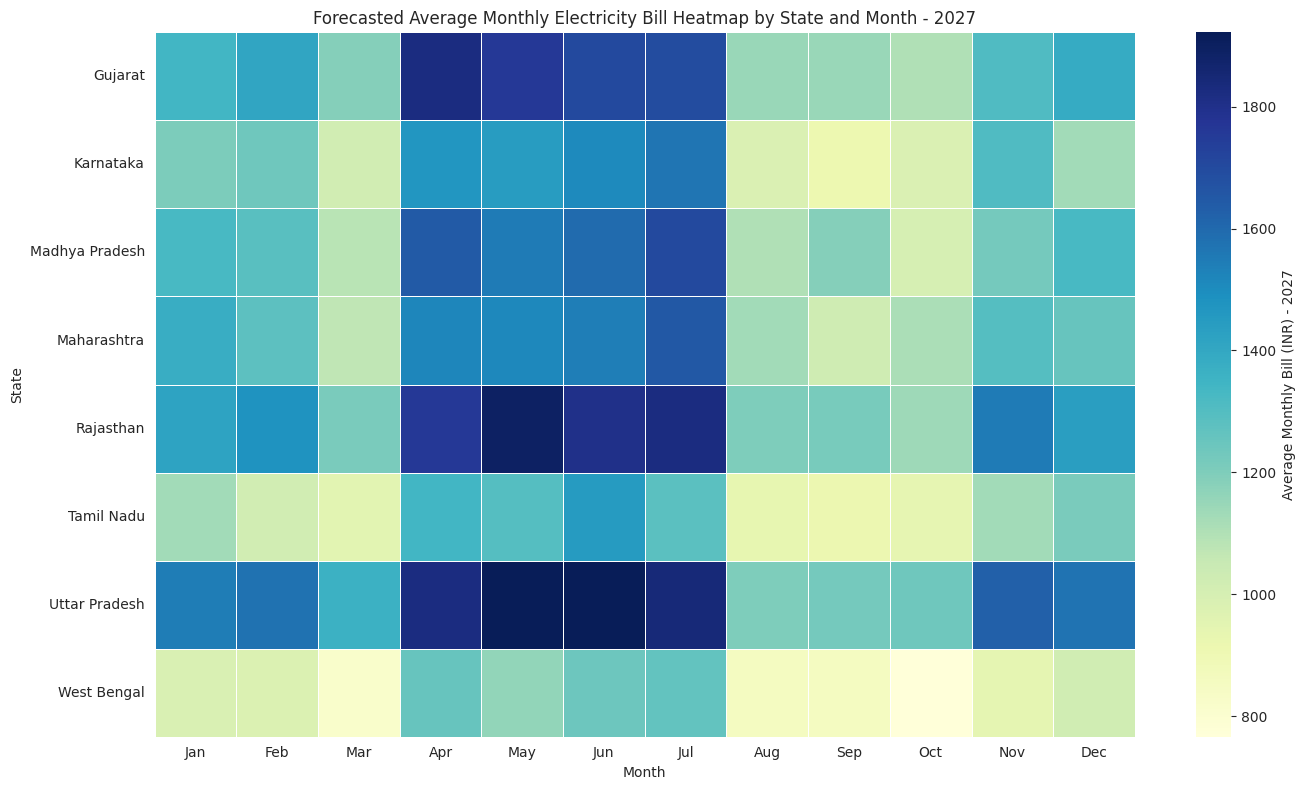

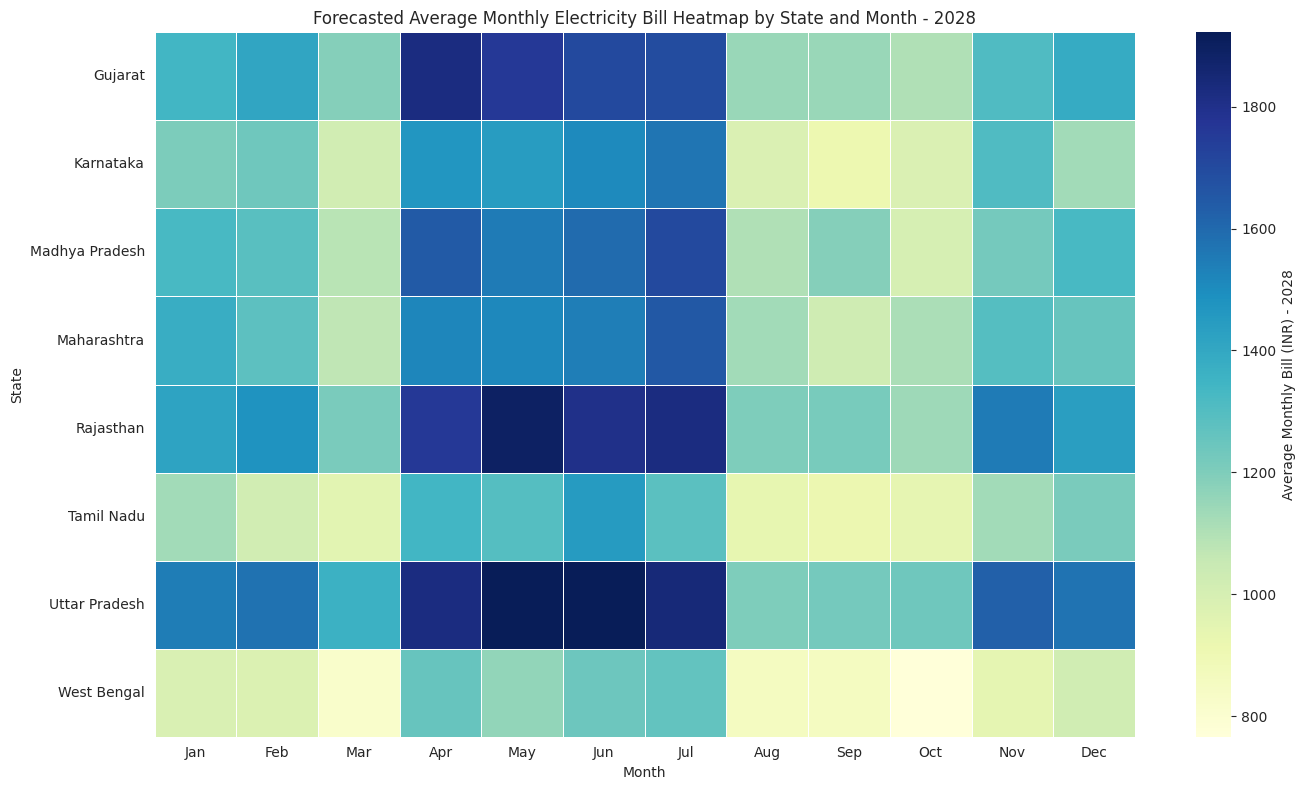

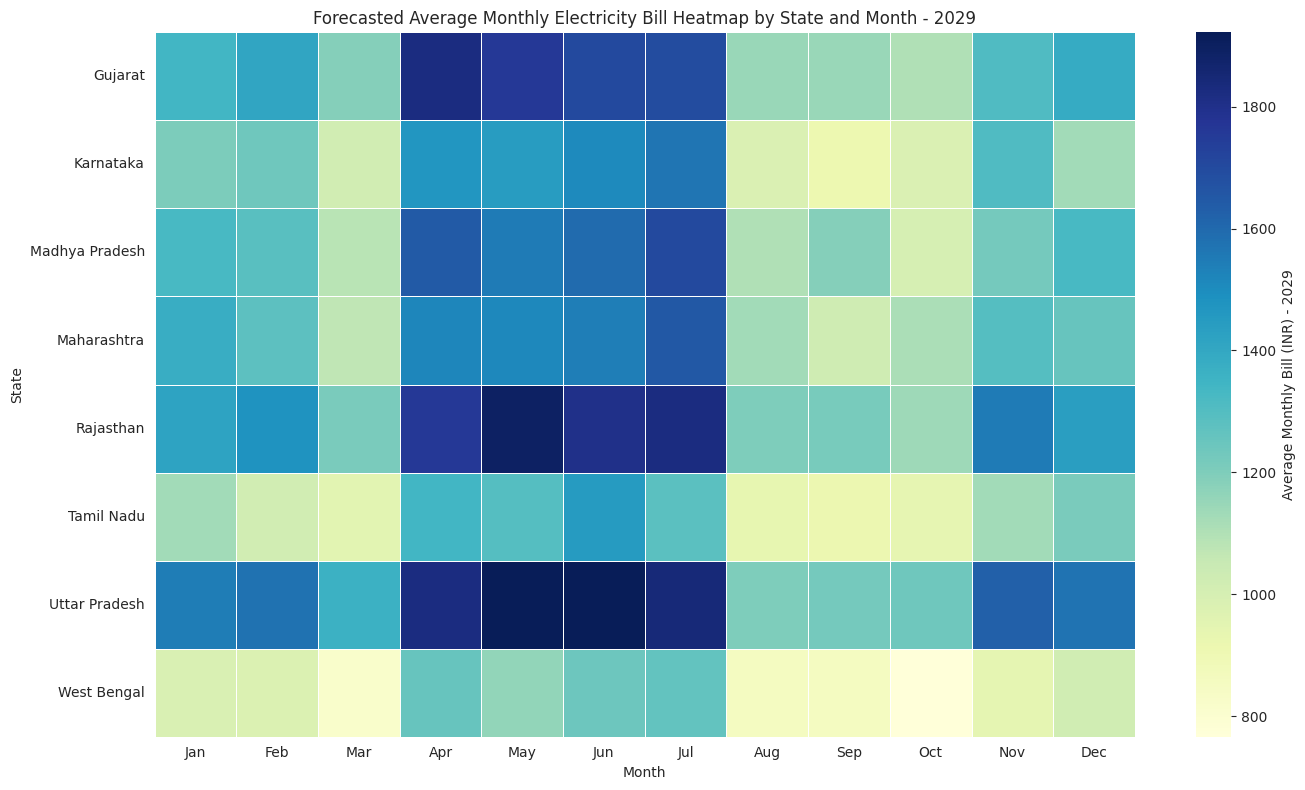

In [38]:
for year in range(2025, 2030):
    # Filter the extended_ensemble_forecast_df for the current year
    yearly_forecast_df = extended_ensemble_forecast_df[extended_ensemble_forecast_df['Date'].dt.year == year]

    # Create a pivot table for the heatmap
    yearly_bill_pivot = yearly_forecast_df.pivot_table(
        index='State',
        columns=yearly_forecast_df['Date'].dt.month,
        values='Monthly_Bill_INR',
        aggfunc='mean' # Use mean as we are averaging over a single year
    )

    plt.figure(figsize=(14, 8))
    sns.heatmap(
        yearly_bill_pivot,
        cmap='YlGnBu',
        fmt=".0f",
        linewidths=.5,
        cbar_kws={'label': f'Average Monthly Bill (INR) - {year}'}
    )
    plt.title(f'Forecasted Average Monthly Electricity Bill Heatmap by State and Month - {year}')
    plt.xlabel('Month')
    plt.ylabel('State')
    plt.xticks(ticks=np.arange(0.5, 12.5), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.tight_layout()
    plt.show()

## Step 10: Interactive Forecast Dashboard

In [45]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ipywidgets import Output

sns.set_style('whitegrid')

# Get unique states from the original DataFrame
state_options = sorted(df['State'].unique().tolist())

# Define the earliest historical year and the latest forecast year
min_year = df['Date'].min().year
max_ensemble_forecast_year = extended_ensemble_forecast_df['Date'].max().year
max_rf_forecast_year = all_state_forecasts['Date'].max().year
max_sarima_forecast_year = all_sarima_plot_df['Date'].max().year

# Create year options (historical + forecast years)
all_years = sorted(list(set(range(min_year, max(max_ensemble_forecast_year, max_rf_forecast_year, max_sarima_forecast_year) + 1))))
year_options = all_years

model_options = ['Ensemble', 'Random Forest', 'SARIMA']

# Create dropdown widgets
state_dropdown = widgets.Dropdown(
    options=state_options,
    value=state_options[0],
    description='State:',
    disabled=False,
    layout=widgets.Layout(width='auto')
)

year_dropdown = widgets.Dropdown(
    options=year_options,
    value=max(year_options), # Default to the latest year
    description='Year for Forecast:',
    disabled=False,
    layout=widgets.Layout(width='auto')
)

model_dropdown = widgets.Dropdown(
    options=model_options,
    value='Ensemble', # Default to Ensemble
    description='Model:',
    disabled=False,
    layout=widgets.Layout(width='auto')
)

# Output widget for displaying the plot
plot_output = Output()

def update_plot(selected_state, selected_year, selected_model):
    with plot_output:
        clear_output(wait=True)

        # Filter historical data (up to 2023-12-31)
        actual_data_plot = df[(df['State'] == selected_state) & (df['Date'].dt.year <= 2023)].copy()
        actual_data_plot['DataType'] = 'Actual'

        plot_data_model = pd.DataFrame()
        forecast_df_source = None
        max_forecast_year_for_model = 0

        if selected_model == 'Ensemble':
            forecast_df_source = extended_ensemble_forecast_df
            max_forecast_year_for_model = max_ensemble_forecast_year
        elif selected_model == 'Random Forest':
            forecast_df_source = all_state_forecasts
            max_forecast_year_for_model = max_rf_forecast_year
        elif selected_model == 'SARIMA':
            forecast_df_source = all_sarima_plot_df
            max_forecast_year_for_model = max_sarima_forecast_year
        else:
            print(f"Error: Invalid model selected '{selected_model}'.")
            return

        # Adjust plot_until_year based on selected_year and model's max forecast year
        plot_until_year = min(selected_year, max_forecast_year_for_model)

        # Get forecast data for the selected state and relevant years
        if forecast_df_source is not None:
            forecast_data_model = forecast_df_source[
                (forecast_df_source['State'] == selected_state) &
                (forecast_df_source['Date'].dt.year >= 2024) &
                (forecast_df_source['Date'].dt.year <= plot_until_year)
            ].copy()
            forecast_data_model['DataType'] = 'Forecast'

            # Combine actuals and forecasts
            plot_data_model = pd.concat([actual_data_plot, forecast_data_model], ignore_index=True)

        if not plot_data_model.empty:
            plot_data_model = plot_data_model.sort_values(by='Date').drop_duplicates(subset=['Date', 'State', 'DataType']).reset_index(drop=True)

            plt.figure(figsize=(16, 9))

            sns.lineplot(
                x='Date', y='Monthly_Bill_INR',
                hue='DataType',
                data=plot_data_model,
                marker='o', markersize=4, lw=1
            )

            plt.title(f'{selected_model} Forecast for {selected_state}: Actual (2019-2023) vs. Forecast (2024-{plot_until_year})')
            plt.xlabel('Date')
            plt.ylabel('Monthly Bill (INR)')
            plt.legend(title='Data Type')
            plt.grid(True, linestyle='--', alpha=0.6)

            # Add a vertical line to indicate the start of the forecast period
            forecast_start_date_plot = pd.to_datetime('2024-01-01') # All models forecast from 2024 onwards relative to historical data
            plt.axvline(x=forecast_start_date_plot, color='red', linestyle=':', label='Forecast Start')
            plt.tight_layout()
            plt.show()
        else:
            print("No data available to plot for the selected parameters. Please check your inputs.")

# Link dropdowns to the update_plot function
widgets.interactive_output(update_plot, {
    'selected_state': state_dropdown,
    'selected_year': year_dropdown,
    'selected_model': model_dropdown
})

# Display the widgets and the plot output
display(widgets.VBox([widgets.HBox([state_dropdown, year_dropdown, model_dropdown]), plot_output]))

## Conclusions

Based on the analysis and forecasting performed, here are the key conclusions:

*   **Data Generation:** A synthetic dataset successfully simulated monthly electricity bills for 8 Indian states, incorporating seasonal and trend variations.
*   **Exploratory Data Analysis (EDA):** EDA revealed clear seasonal patterns (higher bills in summer/winter) and an overall increasing trend in electricity consumption/bills across states.
*   **Feature Engineering:** Lag features, cyclical month encoding, and rolling averages were effective in capturing time-series dynamics for machine learning models.
*   **Model Performance:**
    *   **Random Forest** emerged as the top-performing model with the lowest MAE (3.99) and RMSE (8.54), and an R-squared of 1.00 on the test set, indicating excellent fit to the patterns in the data.
    *   **XGBoost** also performed well, though slightly less accurately than Random Forest.
    *   A **simple Ensemble** model (average of RF and XGBoost) showed performance close to Random Forest.
    *   **SARIMA**, while a traditional time-series model, performed significantly worse (MAE: 114.29, RMSE: 154.46, R-squared: 0.56) and exhibited convergence warnings, suggesting it was less suitable for this specific dataset and its generated parameters.
*   **Forecasting:** The ensemble model (due to its robustness) was used to generate forecasts for monthly electricity bills up to 2029. These forecasts capture the learned seasonal and trend components.
*   **Interactive Visualization:** An interactive dashboard allows users to dynamically explore historical data and future forecasts for individual states, years, and models, enhancing interpretability and usability.

## Forecast Summary Table (2025-2029)

In [46]:
display(extended_ensemble_forecast_df)

,State,Date,Monthly_Bill_INR
0,Gujarat,2025-01-01,1343.983019
1,Gujarat,2025-02-01,1410.971329
2,Gujarat,2025-03-01,1187.929513
3,Gujarat,2025-04-01,1827.334616
4,Gujarat,2025-05-01,1763.742369
...,...,...,...
475,West Bengal,2029-08-01,852.878548
476,West Bengal,2029-09-01,855.888496
477,West Bengal,2029-10-01,766.162272
478,West Bengal,2029-11-01,945.098248
